# CVAE-BIO Computational Pipeline for AMP Discovery


In [ ]:
# Recommended: create the environment from requirements.txt before running this notebook.
# If needed inside Jupyter, uncomment the next line.
# !pip install -r ../requirements.txt


In [ ]:
# Optional environment cleanup can be done here if package conflicts appear.
# Keep this disabled by default to make the notebook more reproducible.


## APD3-Derived Peptide Generation and Downstream Computational Analysis


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.manifold import TSNE

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from features import (
    calculate_aliphatic_proportion,
    calculate_amino_acid_class_properties,
    calculate_boman,
    calculate_charge,
    calculate_hydrophobic_moment,
    calculate_hydrophobicity,
    calculate_physicochemical_properties,
    calculate_stability,
)
from models import AutoEncoder, ConditionalVAE, VAE
from preprocessing import AMINO_ACIDS, build_aa_to_index, build_one_hot_encoder, index_to_aa_mapping
from training import (
    extract_conditioned_z,
    extract_z,
    loss_function,
    reconstruct_sequence,
    set_seed,
    train_cvae,
    train_vae,
    visualize_embeddings,
)


In [2]:
# Create a new label based on the Hydrophobicity
df['Hydrophobicity_pos'] = (df['Hydrophobicity'] > 0.5).astype(int)
# Create a new label based on the Amphiphilicity
df['Amphiphilicity_pos'] = (df['Amphiphilicity'] > 0.4).astype(int)
# Create a new label based on the Amphiphilicity
df['Charge_pos'] = (df['Charge'] > 2 ).astype(int)
# Create a new label based on the Amphiphilicity
df['Charge_neg'] = (df['Charge'] < 8).astype(int)

# Display the updated DataFrame
print(df.head())

    APD ID                                     Sequence  Activity  \
0  AP00001            GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV    Active   
1  AP00002           YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY  Unactive   
2  AP00006                           GNNRPVYIPQPRPPHPRI    Active   
3  AP00007                           GNNRPVYIPQPRPPHPRL    Active   
4  AP00009  RFRPPIRRPPIRPPFYPPFRPPIRPPIFPPIRPPFRPPLGPFP    Active   

   Rough Concentration (?/mL)  Rough Molecular Weight (length * 120)  \
0                        15.0                                   3960   
1                        50.0                                   4080   
2                         0.1                                   2160   
3                         0.1                                   2160   
4                        12.0                                   5160   

      label  Hydrophobicity  Amphiphilicity    Charge  Hydrophobicity_pos  \
0  Inactive        0.196970        0.677535  3.001539                   0  

In [ ]:
# Peptide property helper functions were moved to src/features.py.
# They are imported in the setup cell above.


In [ ]:
# Sequence-level helper functions were moved to src/features.py.
# They are imported in the setup cell above.


In [5]:
# Create a variable for length
df['Length'] = df['Sequence'].apply(len)
# Create a variable for length
df['Boman'] = df['Sequence'].apply(calculate_boman)
# Create a variable for length
df['Instability'] = df['Sequence'].apply(calculate_stability)
# Create a new label based on the length
df['Length_pos'] = (df['Length'] < 40).astype(int)
# Create a new label based on the length
df['Length_neg'] = (df['Length'] > 0).astype(int)
# Create a new label based on the length
df['Instability_pos'] = (df['Instability'] < 40).astype(int)
# Create a new label based on the length
df['Boman_pos'] = (df['Boman'] < 0).astype(int)

In [ ]:
import tensorflow as tf

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
amino_acids = AMINO_ACIDS
aa_to_index = build_aa_to_index(amino_acids)
index_to_aa = index_to_aa_mapping(amino_acids)
max_length = df['Sequence'].str.len().max()
one_hot_encode_sequence = build_one_hot_encoder(max_length=max_length, amino_acids=amino_acids)
df['OneHotEncoded'] = df['Sequence'].apply(one_hot_encode_sequence)


In [8]:
# Step 2: Rename the columns as "SeqLength", "Sequence", and "id_ref"
#X_df = X_df.rename(columns={'Length': 'SeqLength', 'APD ID': 'id_ref'})

import pandas as pd
from sklearn.model_selection import train_test_split
# Step 2: Split the data into features and labels
y = df['label']  # Assuming 'label' contains 'Inactive' and 'Active'

# Step 3: First split into training + validation and testing sets
df_train, df_test, y_temp, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=42)
y_train= y_temp
#df_train = df

# Step 7: Encode labels as integers
# Map activity labels to integers
label_to_index = {label: idx for idx, label in enumerate(df_test['label'].unique())}
y_test_encoded = df_test['label'].map(label_to_index).values  # Convert to integer array


In [9]:
# Step 6: Convert the one-hot encoded sequences to a matrix
X = np.array(df_train['OneHotEncoded'].tolist())

In [10]:
# Step 7: Encode labels as integers
# Map activity labels to integers
label_to_index = {label: idx for idx, label in enumerate(df_train['label'].unique())}
y_1 = df_train['label'].map(label_to_index).values  # Convert to integer array

In [11]:
# Step 7: Encode labels as integers
# Map activity labels to integers
label_to_index = {label: idx for idx, label in enumerate(df_train['Boman_pos'].unique())}
y_2 = df_train['Boman_pos'].values  # Convert to integer array

In [12]:
# Step 7: Encode labels as integers
# Map length labels to integers
#label_to_index = {label: idx for idx, label in enumerate(df_train['Length_pos'].unique())}
#y_2 = df_train['Length_pos'].values  # Convert to integer array

In [12]:
# Step 7: Encode labels as integers
# Map length labels to integers
label_to_index = {label: idx for idx, label in enumerate(df_train['Instability_pos'].unique())}
y_3 = df_train['Instability_pos'].values  # Convert to integer array

In [14]:
# Step 7: Encode labels as integers
# Map length labels to integers
#label_to_index = {label: idx for idx, label in enumerate(df_train['Hydrophobicity_pos'].unique())}
#y_4 = df_train['Hydrophobicity_pos'].values  # Convert to integer array

In [13]:
# Step 7: Encode labels as integers
# Map length labels to integers
label_to_index = {label: idx for idx, label in enumerate(df_train['Charge_pos'].unique())}
y_4 = df_train['Charge_pos'].values  # Convert to integer array

In [14]:
# Step 7: Encode labels as integers
# Map length labels to integers
label_to_index = {label: idx for idx, label in enumerate(df_train['Length_pos'].unique())}
y_5 = df_train['Length_pos'].values  # Convert to integer array

In [ ]:
# AutoEncoder was moved to src/models.py.
# It is imported in the setup cell above.


In [ ]:
learning_rate = 1e-3
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not isinstance(X, torch.Tensor):
    X_tensor = torch.from_numpy(X).float().to(device)
else:
    X_tensor = X.float().to(device)

model = AutoEncoder(input_dim=max_length * len(amino_acids))
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
model.to(device)

train_loader = torch.utils.data.DataLoader(
    dataset=X_tensor,
    batch_size=batch_size,
    shuffle=True,
)

num_epochs = 100
for epoch in range(num_epochs):
    total_loss = 0.0
    for data in train_loader:
        data = data.to(device)
        _, decoded = model(data)
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}: loss={epoch_loss:.4f}")


In [ ]:
# This logic was moved to src/ and is imported in the setup cell above.


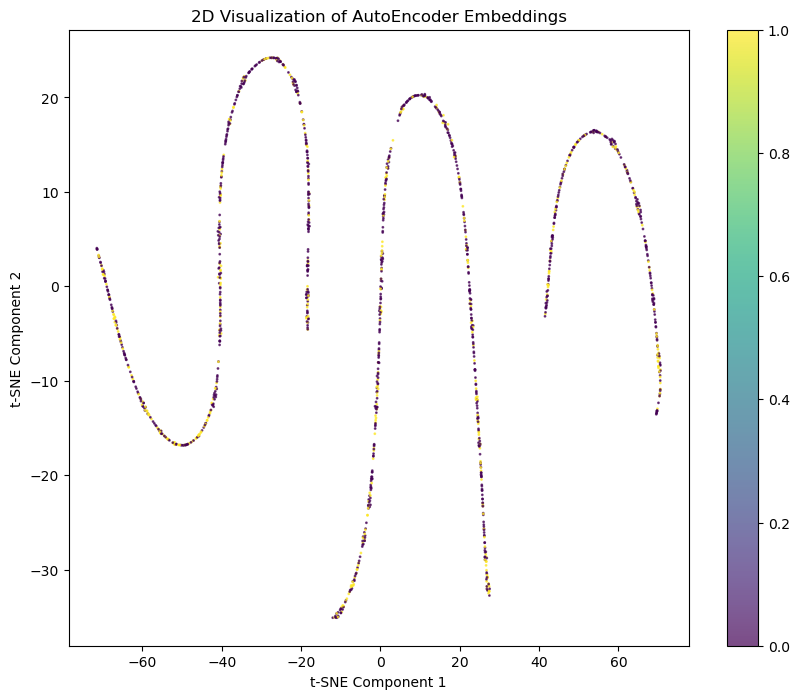

In [18]:
# Example usage (assuming X and y_train are defined)
visualize_embeddings(model, X, y_1)

In [ ]:
# This logic was moved to src/ and is imported in the setup cell above.


In [ ]:
# This logic was moved to src/ and is imported in the setup cell above.


In [ ]:
# This logic was moved to src/ and is imported in the setup cell above.


In [22]:
# Assuming you have already trained your model
vae_model = train_vae(X)

Epoch 1/100: loss=3763.7180
Epoch 2/100: loss=815.3208
Epoch 3/100: loss=799.3014
Epoch 4/100: loss=787.9986
Epoch 5/100: loss=780.0168
Epoch 6/100: loss=776.1783
Epoch 7/100: loss=771.2687
Epoch 8/100: loss=770.1478
Epoch 9/100: loss=768.4881
Epoch 10/100: loss=765.7596
Epoch 11/100: loss=762.8363
Epoch 12/100: loss=763.0282
Epoch 13/100: loss=761.4851
Epoch 14/100: loss=760.1128
Epoch 15/100: loss=759.9024
Epoch 16/100: loss=758.9822
Epoch 17/100: loss=759.3872
Epoch 18/100: loss=756.9994
Epoch 19/100: loss=757.9071
Epoch 20/100: loss=755.8930
Epoch 21/100: loss=756.7277
Epoch 22/100: loss=756.6030
Epoch 23/100: loss=757.8680
Epoch 24/100: loss=756.5387
Epoch 25/100: loss=757.5385
Epoch 26/100: loss=755.4569
Epoch 27/100: loss=754.0457
Epoch 28/100: loss=756.8293
Epoch 29/100: loss=755.7860
Epoch 30/100: loss=755.8025
Epoch 31/100: loss=755.2251
Epoch 32/100: loss=756.0651
Epoch 33/100: loss=756.1684
Epoch 34/100: loss=755.5717
Epoch 35/100: loss=754.3106
Epoch 36/100: loss=754.2117


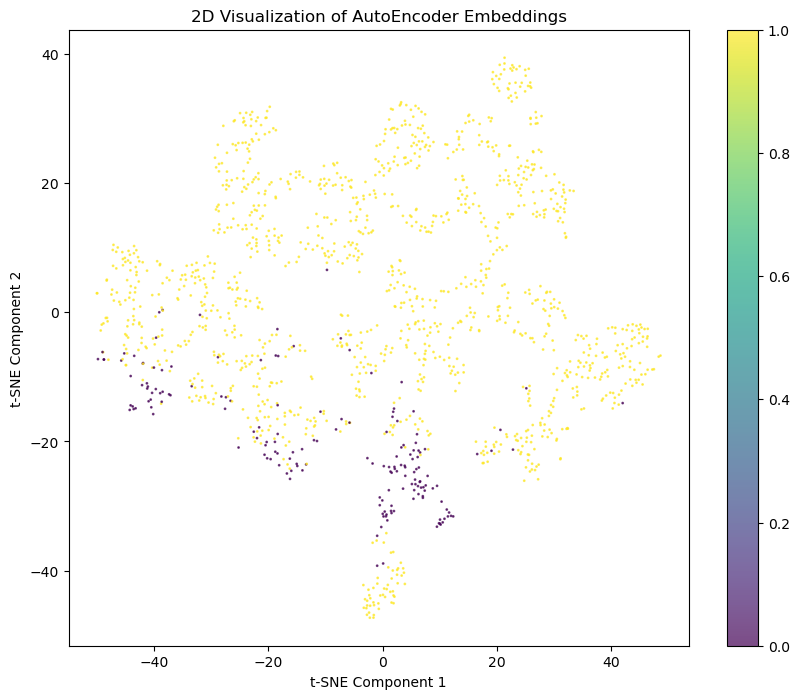

In [23]:
visualize_embeddings(vae_model, X, y_5)

## **APD peptide 5 projector Conditional VAE**

In [ ]:
# This logic was moved to src/ and is imported in the setup cell above.


In [ ]:
num_classes_1 = 2
num_classes_2 = 2
num_classes_3 = 2
num_classes_4 = 2
num_classes_5 = 2
trained_cvae = train_cvae(
    X,
    y_1,
    y_2,
    y_3,
    y_4,
    y_5,
    num_classes_1,
    num_classes_2,
    num_classes_3,
    num_classes_4,
    num_classes_5,
    num_epochs=500,
    device=device,
    input_dim=max_length * len(amino_acids),
)


In [ ]:
conditioned_z_all = extract_conditioned_z(
    trained_cvae,
    X,
    y_1,
    y_2,
    y_3,
    y_4,
    y_5,
    num_classes=(num_classes_1, num_classes_2, num_classes_3, num_classes_4, num_classes_5),
    batch_size=32,
    device=device,
)

tsne = TSNE(n_components=2, random_state=42)
conditioned_z_2d = tsne.fit_transform(conditioned_z_all)

for labels, title in [
    (y_1, 'y_1'),
    (y_2, 'y_2'),
    (y_3, 'y_3'),
    (y_4, 'y_4'),
    (y_5, 'y_5'),
]:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(conditioned_z_2d[:, 0], conditioned_z_2d[:, 1], s=10, alpha=0.7, c=labels, cmap='viridis')
    plt.colorbar(scatter)
    plt.title(f'2D t-SNE Visualization of Conditioned Latent Space ({title})', fontsize=16)
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.show()


In [ ]:
z_all = extract_z(trained_cvae, X, batch_size=32, device=device)

tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z_all)

for labels, title in [
    (y_1, 'y_1'),
    (y_2, 'y_2'),
    (y_3, 'y_3'),
    (y_4, 'y_4'),
    (y_5, 'y_5'),
]:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], s=10, alpha=0.7, c=labels, cmap='viridis')
    plt.colorbar(scatter)
    plt.title(f'2D t-SNE Visualization of Unconditioned Latent Space ({title})', fontsize=16)
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.show()


Reconstructed sequence df_train

In [27]:
import torch
import numpy as np

# Select the first 10 images from X_test
#first_10_images = X[:10]  # Shape: (10, 28, 28)
first_10_images = X
if not isinstance(first_10_images, torch.Tensor):
    first_10_images_tensor = torch.from_numpy(first_10_images).float().to(device)  # Convert to tensor and move to device
else:
    first_10_images_tensor = first_10_images.float().to(device)  # Ensure it's float and move to device
    
# Create a one-hot encoded label for digit 8
label_1_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_2_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_3_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_4_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_5_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)


# Pass the first 10 images and label to the conditional VAE's decoder
with torch.no_grad():
    encoded, decoded, mu, log_var , hid_fea = trained_cvae(first_10_images_tensor, label_1_2, label_2_2, label_3_2, label_4_2, label_5_2)

In [28]:
import torch
import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.manifold import TSNE
embedding_CVAE_train = encoded.cpu().detach().numpy()

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
embedding_CVAE_train = encoded.cpu().detach().numpy()
# Use t-SNE to reduce dimensionality to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embedding_CVAE_train)

# Plot the 2D embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=1, alpha=0.7, c=y_1)
plt.colorbar(scatter)  # Add a color bar to indicate labels
plt.title('2D Visualization of AutoEncoder Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

: 

In [ ]:
reconstructed_sequences = reconstruct_sequence(decoded, max_length)
reconstructed_sequences = [seq.replace("-", "") for seq in reconstructed_sequences]

for i, seq in enumerate(reconstructed_sequences):
    print(f"{df_train['APD ID'].iloc[i]},{df_train['Sequence'].iloc[i]}, {seq}")


Generated Result

In [30]:
generated_results = pd.DataFrame()
generated_results['APD ID'] = df_train['APD ID']
generated_results['Sequence'] = df_train['Sequence']
generated_results['Label'] = df_train['label']
generated_results['Reconstructed_sequences'] = reconstructed_sequences
generated_results['Active_proba'] = 1
generated_results['Boman_ori'] = [calculate_boman(seq) for seq in df_train['Sequence']] 
generated_results['Boman_re'] = [calculate_boman(seq) for seq in reconstructed_sequences] 
generated_results['Hydrophobicity_ori'] = [calculate_hydrophobicity(seq) for seq in df_train['Sequence']] 
generated_results['Hydrophobicity_re'] = [calculate_hydrophobicity(seq) for seq in reconstructed_sequences] 
generated_results['Length_ori'] = [len(seq) for seq in df_train['Sequence']] 
generated_results['Length_re'] = [len(seq) for seq in reconstructed_sequences] 
generated_results['Stability_ori'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in df_train['Sequence']]
generated_results['Stability_re'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in reconstructed_sequences]
generated_results['Charge_ori'] = [calculate_charge(seq) for seq in df_train['Sequence']] 
generated_results['Charge_re'] = [calculate_charge(seq) for seq in reconstructed_sequences] 

In [31]:
generated_results_df_train = generated_results

In [32]:
sum(generated_results['Stability_re'] < 40)

1440

In [33]:
sum(generated_results['Stability_ori'] < 40)

1075

In [34]:
sum(generated_results['Length_re'] < 40)

1486

In [35]:
sum(generated_results['Length_ori'] < 40)

1316

In [36]:
sum(generated_results['Charge_re'] > 0)

1484

In [37]:
sum(generated_results['Charge_ori'] > 0)

1445

In [38]:
sum((generated_results['Charge_re'] > 2))


1278

In [39]:
sum((generated_results['Charge_ori']>2))

1094

In [525]:
sum(generated_results['Hydrophobicity_re'] > 0.5)

55

In [242]:
sum(generated_results['Hydrophobicity_ori'] > 0.5)

505

In [40]:
sum(generated_results['Boman_re'] < 0)

1267

In [41]:
sum(generated_results['Boman_ori'] < 0)

485

Reconstructed sequence Reconstructed from df_train

In [42]:
import torch
import numpy as np

# Select the first 10 images from X_test
#first_10_images = X[:10]  # Shape: (10, 28, 28)
# Step 6: Convert the one-hot encoded sequences to a matrix

# Step 5: Apply one-hot encoding to each sequence and flatten it
generated_results['OneHotEncoded'] = generated_results['Reconstructed_sequences'].apply(one_hot_encode_sequence)
first_10_images  = np.array(generated_results['OneHotEncoded'].tolist())

if not isinstance(first_10_images, torch.Tensor):
    first_10_images_tensor = torch.from_numpy(first_10_images).float().to(device)  # Convert to tensor and move to device
else:
    first_10_images_tensor = first_10_images.float().to(device)  # Ensure it's float and move to device
    
# Create a one-hot encoded label for digit 8
label_1_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_2_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_3_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_4_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_5_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)


# Pass the first 10 images and label to the conditional VAE's decoder
with torch.no_grad():
    encoded, decoded, mu, log_var , hid_fea = trained_cvae(first_10_images_tensor, label_1_2, label_2_2, label_3_2, label_4_2, label_5_2)

In [43]:
import torch
import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.manifold import TSNE
embedding_CVAE_train_recontruct = encoded.cpu().detach().numpy()

In [ ]:
reconstructed_sequences = reconstruct_sequence(decoded, max_length)
reconstructed_sequences = [seq.replace("-", "") for seq in reconstructed_sequences]

for i, seq in enumerate(reconstructed_sequences):
    print(f"{generated_results['APD ID'].iloc[i]},{generated_results['Reconstructed_sequences'].iloc[i]}, {seq}")


Generated Result

In [45]:
generated_results_gen = pd.DataFrame()
generated_results_gen['APD ID'] = generated_results['APD ID']
generated_results_gen['Sequence'] = generated_results['Reconstructed_sequences']
generated_results_gen['Label'] = generated_results['Label']
generated_results_gen['Reconstructed_sequences'] = reconstructed_sequences
generated_results_gen['Active_proba'] = 1
generated_results_gen['Boman_ori'] = [calculate_boman(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Boman_re'] = [calculate_boman(seq) for seq in reconstructed_sequences] 
generated_results_gen['Hydrophobicity_ori'] = [calculate_hydrophobicity(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Hydrophobicity_re'] = [calculate_hydrophobicity(seq) for seq in reconstructed_sequences] 
generated_results_gen['Length_ori'] = [len(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Length_re'] = [len(seq) for seq in reconstructed_sequences] 
generated_results_gen['Stability_ori'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in generated_results['Reconstructed_sequences']]
generated_results_gen['Stability_re'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in reconstructed_sequences]
generated_results_gen['Charge_ori'] = [calculate_charge(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Charge_re'] = [calculate_charge(seq) for seq in reconstructed_sequences] 

In [46]:
generated_results_df_train_generated = generated_results_gen

In [47]:
sum(generated_results_gen['Stability_re'] < 40)

1453

In [48]:
sum(generated_results_gen['Stability_ori'] < 40)

1440

In [49]:
sum(generated_results_gen['Length_re'] < 40)

1490

In [50]:
sum(generated_results_gen['Length_ori'] < 40)

1486

In [51]:
sum(generated_results_gen['Charge_re'] > 2)

1342

In [52]:
sum(generated_results_gen['Charge_ori'] > 2)

1278

In [53]:
sum(generated_results_gen['Boman_re'] < 0)

1308

In [54]:
sum(generated_results_gen['Boman_ori'] < 0)

1267

Reconstructed sequence df_test

In [55]:
import torch
import numpy as np

# Select the first 10 images from X_test
#first_10_images = X[:10]  # Shape: (10, 28, 28)
# Step 6: Convert the one-hot encoded sequences to a matrix
first_10_images  = np.array(df_test['OneHotEncoded'].tolist())

if not isinstance(first_10_images, torch.Tensor):
    first_10_images_tensor = torch.from_numpy(first_10_images).float().to(device)  # Convert to tensor and move to device
else:
    first_10_images_tensor = first_10_images.float().to(device)  # Ensure it's float and move to device
    
# Create a one-hot encoded label for digit 8
label_1_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_2_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_3_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_4_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_5_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)


# Pass the first 10 images and label to the conditional VAE's decoder
with torch.no_grad():
    encoded, decoded, mu, log_var , hid_fea = trained_cvae(first_10_images_tensor, label_1_2, label_2_2, label_3_2, label_4_2, label_5_2)

In [56]:
import torch
import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.manifold import TSNE
embedding_CVAE_test = encoded.cpu().detach().numpy()

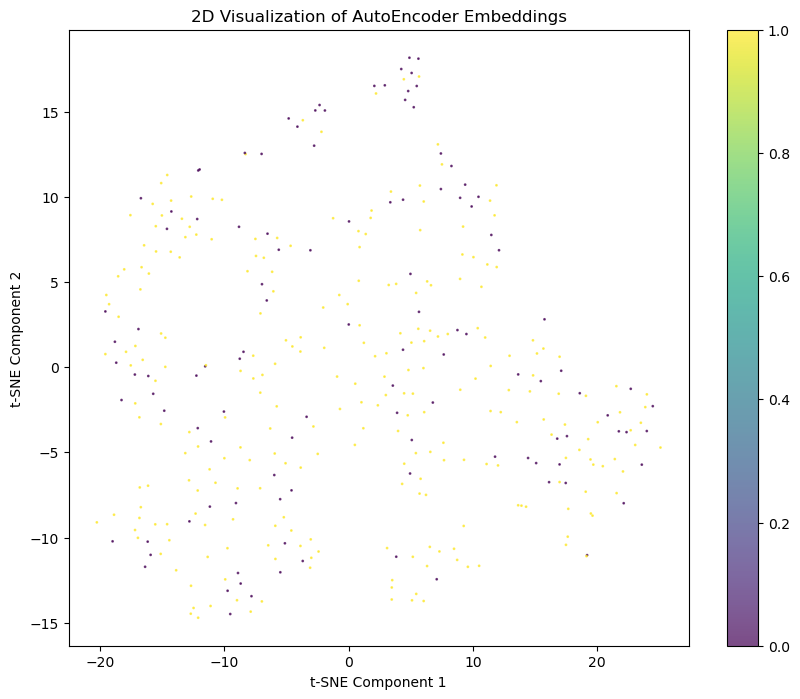

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
embedding_CVAE_test = encoded.cpu().detach().numpy()
# Use t-SNE to reduce dimensionality to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embedding_CVAE_test)

# Plot the 2D embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=1, alpha=0.7, c=y_test_encoded)
plt.colorbar(scatter)  # Add a color bar to indicate labels
plt.title('2D Visualization of AutoEncoder Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [ ]:
reconstructed_sequences = reconstruct_sequence(decoded, max_length)
reconstructed_sequences = [seq.replace("-", "") for seq in reconstructed_sequences]

for i, seq in enumerate(reconstructed_sequences):
    print(f"{df_test['APD ID'].iloc[i]},{df_test['Sequence'].iloc[i]}, {seq}")


Generated Result

In [59]:
generated_results = pd.DataFrame()
generated_results['APD ID'] = df_test['APD ID']
generated_results['Sequence'] = df_test['Sequence']
generated_results['Label'] = df_test['label']
generated_results['Reconstructed_sequences'] = reconstructed_sequences
generated_results['Active_proba'] = 1
generated_results['Boman_ori'] = [calculate_boman(seq) for seq in df_test['Sequence']] 
generated_results['Boman_re'] = [calculate_boman(seq) for seq in reconstructed_sequences] 
generated_results['Hydrophobicity_ori'] = [calculate_hydrophobicity(seq) for seq in df_test['Sequence']] 
generated_results['Hydrophobicity_re'] = [calculate_hydrophobicity(seq) for seq in reconstructed_sequences] 
generated_results['Length_ori'] = [len(seq) for seq in df_test['Sequence']] 
generated_results['Length_re'] = [len(seq) for seq in reconstructed_sequences] 
generated_results['Stability_ori'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in df_test['Sequence']]
generated_results['Stability_re'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in reconstructed_sequences]
generated_results['Charge_ori'] = [calculate_charge(seq) for seq in df_test['Sequence']] 
generated_results['Charge_re'] = [calculate_charge(seq) for seq in reconstructed_sequences] 

In [60]:
generated_results_df_test = generated_results

In [61]:
sum(generated_results['Stability_re'] < 40)

371

In [62]:
sum(generated_results['Stability_ori'] < 40)

285

In [63]:
sum(generated_results['Length_re'] < 40)

373

In [64]:
sum(generated_results['Length_ori'] < 40)

329

In [65]:
sum(generated_results['Charge_re'] > 2)

338

In [66]:
sum(generated_results['Charge_ori'] > 2)

276

In [67]:
sum(generated_results['Boman_re'] < 0)

329

In [68]:
sum(generated_results['Boman_ori'] < 0)

115

Reconstructed sequence Reconstructed from df_test

In [69]:
import torch
import numpy as np

# Select the first 10 images from X_test
#first_10_images = X[:10]  # Shape: (10, 28, 28)
# Step 6: Convert the one-hot encoded sequences to a matrix

# Step 5: Apply one-hot encoding to each sequence and flatten it
generated_results['OneHotEncoded'] = generated_results['Reconstructed_sequences'].apply(one_hot_encode_sequence)
first_10_images  = np.array(generated_results['OneHotEncoded'].tolist())

if not isinstance(first_10_images, torch.Tensor):
    first_10_images_tensor = torch.from_numpy(first_10_images).float().to(device)  # Convert to tensor and move to device
else:
    first_10_images_tensor = first_10_images.float().to(device)  # Ensure it's float and move to device
    
# Create a one-hot encoded label for digit 8
label_1_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_2_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_3_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_4_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)

# Create a one-hot encoded label for digit 8
label_5_2 = torch.nn.functional.one_hot(torch.tensor([1] * len(first_10_images)), num_classes=2).float().to(device)


# Pass the first 10 images and label to the conditional VAE's decoder
with torch.no_grad():
    encoded, decoded, mu, log_var , hid_fea = trained_cvae(first_10_images_tensor, label_1_2, label_2_2, label_3_2, label_4_2, label_5_2)

In [70]:
import torch
import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.manifold import TSNE
embedding_CVAE_test_reconstruct = encoded.cpu().detach().numpy()

In [ ]:
reconstructed_sequences = reconstruct_sequence(decoded, max_length)
reconstructed_sequences = [seq.replace("-", "") for seq in reconstructed_sequences]

for i, seq in enumerate(reconstructed_sequences):
    print(f"{generated_results_gen['APD ID'].iloc[i]},{generated_results_gen['Reconstructed_sequences'].iloc[i]}, {seq}")


Generated Result

In [72]:
generated_results_gen = pd.DataFrame()
generated_results_gen['APD ID'] = generated_results['APD ID']
generated_results_gen['Sequence'] = generated_results['Reconstructed_sequences']
generated_results_gen['Label'] = generated_results['Label']
generated_results_gen['Reconstructed_sequences'] = reconstructed_sequences
generated_results_gen['Active_proba'] = 1
generated_results_gen['Boman_ori'] = [calculate_boman(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Boman_re'] = [calculate_boman(seq) for seq in reconstructed_sequences] 
generated_results_gen['Hydrophobicity_ori'] = [calculate_hydrophobicity(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Hydrophobicity_re'] = [calculate_hydrophobicity(seq) for seq in reconstructed_sequences] 
generated_results_gen['Length_ori'] = [len(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Length_re'] = [len(seq) for seq in reconstructed_sequences] 
generated_results_gen['Stability_ori'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in generated_results['Reconstructed_sequences']]
generated_results_gen['Stability_re'] = [calculate_stability(seq) if len(seq) > 1 else float('inf') for seq in reconstructed_sequences]
generated_results_gen['Charge_ori'] = [calculate_charge(seq) for seq in generated_results['Reconstructed_sequences']] 
generated_results_gen['Charge_re'] = [calculate_charge(seq) for seq in reconstructed_sequences] 

In [73]:
generated_results_df_test_generated = generated_results_gen

In [74]:
sum(generated_results_gen['Stability_re'] < 40)

364

In [75]:
sum(generated_results_gen['Stability_ori'] < 40)

371

In [76]:
sum(generated_results_gen['Length_re'] < 40)

373

In [77]:
sum(generated_results_gen['Length_ori'] < 40)

373

In [78]:
sum(generated_results_gen['Charge_re'] > 2)

341

In [79]:
sum(generated_results_gen['Charge_ori'] > 2)

338

In [80]:
sum(generated_results_gen['Boman_re'] < 0)

320

In [81]:
sum(generated_results_gen['Boman_ori'] < 0)

329

# **Linear Model following the generator**

In [82]:
import pandas as pd
import numpy as np

# Step 1: Read the CSV file
# Replace 'peptides.csv' with your actual file path
#df = pd.read_csv('APD_ac_10_label.csv')
import numpy as np
# Create a variable for length
#df['Length'] = df['Sequence'].apply(len)
# Step 1: Extract the relevant columns from the DataFrame
# Selecting "Length", "Sequence", and "APD ID" columns
X_df_train = df_train[[ 'APD ID','Sequence','Length', 'Hydrophobicity','Charge']]
X_df_test = df_test[[ 'APD ID','Sequence','Length', 'Hydrophobicity','Charge']]


In [ ]:
properties_df_AA_train = X_df_train['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_train = properties_df_AA_train.iloc[:, 1:]
properties_df_AA_test = X_df_test['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_train = X_df_train['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)
properties_df_fea_test = X_df_test['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_train = np.array(df_train['OneHotEncoded'].tolist())
X_test = np.array(df_test['OneHotEncoded'].tolist())
z_train_all = extract_z(trained_cvae, X_train, device=device)
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_train_df = pd.DataFrame(z_train_all, columns=[f'z_{i+1}' for i in range(z_train_all.shape[1])])
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])
z_train_df_reset = z_train_df.reset_index(drop=True)
z_test_df_reset = z_test_df.reset_index(drop=True)


In [86]:
# Convert the z_all array to a DataFrame and rename columns
z_train_df = pd.DataFrame(embedding_CVAE_train , columns=[f'z_{i+1}' for i in range(embedding_CVAE_train.shape[1])])
z_test_df = pd.DataFrame(embedding_CVAE_test, columns=[f'z_{i+1}' for i in range(embedding_CVAE_test.shape[1])])

# Reset the indices of both DataFrames to ensure alignment
z_train_df_reset = z_train_df.reset_index(drop=True)
z_test_df_reset = z_test_df.reset_index(drop=True)

In [87]:

# Concatenate the new properties with the original DataFrame
X_df_train = pd.concat([X_df_train.reset_index(drop=True), properties_df_AA_train.reset_index(drop=True) , properties_df_fea_train.reset_index(drop=True),z_train_df.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_df_test = pd.concat([X_df_test.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True),z_test_df.reset_index(drop=True)], axis=1)



In [88]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_val are pandas Series containing 'Inactive' and 'Active'
# Example:
# y_train = pd.Series(['Active', 'Inactive', 'Active', ...])
# y_val = pd.Series(['Inactive', 'Active', ...])

# Step 1: Initialize LabelEncoder
label_encoder = LabelEncoder()

# Step 2: Fit and transform your labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Step 2: Fit and transform your labels
y_test_encoded = label_encoder.fit_transform(y_test)
y_test_res = np.array(y_test_encoded.astype('float32').reshape((-1, 1)))

In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [90]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Implement GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_df_train.iloc[:, 2:], y_train_encoded)

# Best model and parameters
best_rf_model_with_z = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
87 fits failed with the following error:
Traceback (most recent call last):
  File "/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constr

Best Parameters: {'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Confusion Matrix:
 [[ 56  58]
 [ 34 225]]


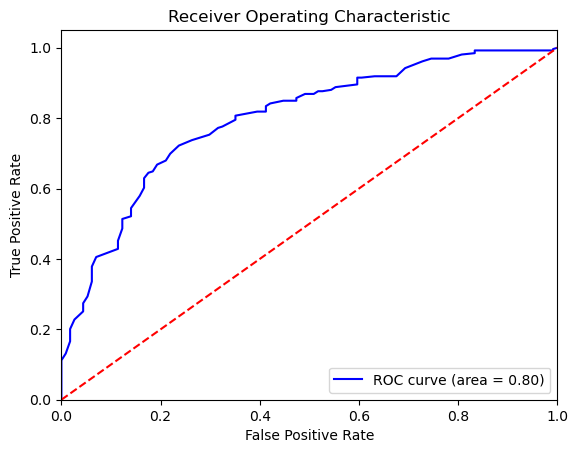

In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Example data creation (replace this with your actual data loading)
from sklearn.datasets import make_classification


# Make predictions
predictions = best_rf_model_with_z.predict(X_df_test.iloc[:, 2:])
predicted_proba = best_rf_model_with_z.predict_proba(X_df_test.iloc[:, 2:])[:, 1]  # Probability estimates for the positive class

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, predictions)
print("Confusion Matrix:\n", conf_matrix)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_encoded, predicted_proba)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [92]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Assuming you have your model and test set ready
# Get predicted probabilities for class 0 (probability of class 0)
predicted_proba = best_rf_model_with_z.predict_proba(X_df_test.iloc[:, 2:])[:, 0]  # Probability of class 0

# Initialize variables to track the best threshold and its corresponding precision for class 0
best_threshold = 0.0
best_precision = 0.0
best_conf_matrix = None

# Evaluate thresholds from 0.0 to 1.0 in steps (e.g., 0.01)
thresholds = np.arange(0.0, 1.01, 0.01)  # Include 1.0
thresholds = np.arange(0.58, 0.61, 0.01)
for threshold in thresholds:
    # Make predictions based on the current threshold
    # Predict class 0 if prob of 0 >= threshold, else class 1
    predictions = (1-(predicted_proba >= threshold)).astype(int)  # 0 if prob >= threshold, 1 otherwise
    
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test_encoded, predictions)
    
    # Extract True Negatives (TN) and False Negatives (FN)
    tn = conf_matrix[0, 0]  # True Negatives
    fn = conf_matrix[1, 0]  # False Negatives
    predicted_negatives = tn + fn  # Total predicted negatives (0 predictions)
    
    # Calculate precision for class 0 (TN / (TN + FN))
    precision_class_0 = tn / predicted_negatives if predicted_negatives > 0 else 0
    
    # Update the best threshold if the current precision is higher
    if precision_class_0 > best_precision:
        best_precision = precision_class_0
        best_threshold = threshold
        best_conf_matrix = conf_matrix  # Store the best confusion matrix

# Output the best threshold and corresponding precision for predicting 0
print("Best Threshold for Class 0 Precision:", best_threshold)
print("Best Class 0 Prediction Precision:", best_precision)

# Present the corresponding confusion matrix
print("Confusion Matrix with Best Threshold:\n", best_conf_matrix)

Best Threshold for Class 0 Precision: 0.61
Best Class 0 Prediction Precision: 0.7
Confusion Matrix with Best Threshold:
 [[ 35  79]
 [ 15 244]]


Best Threshold with at least 0.8 Precision for Class 0: 0.6900000000000001
Best Class 0 Precision (>= 0.8): 0.8260869565217391
Number of Class 0 Predictions at Best Threshold: 23
Confusion Matrix with Best Threshold:
 [[ 19  95]
 [  4 255]]


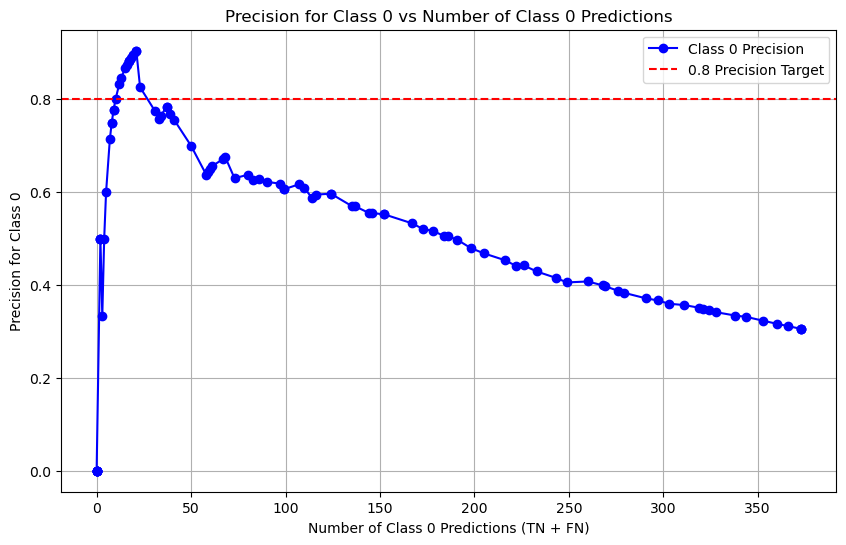

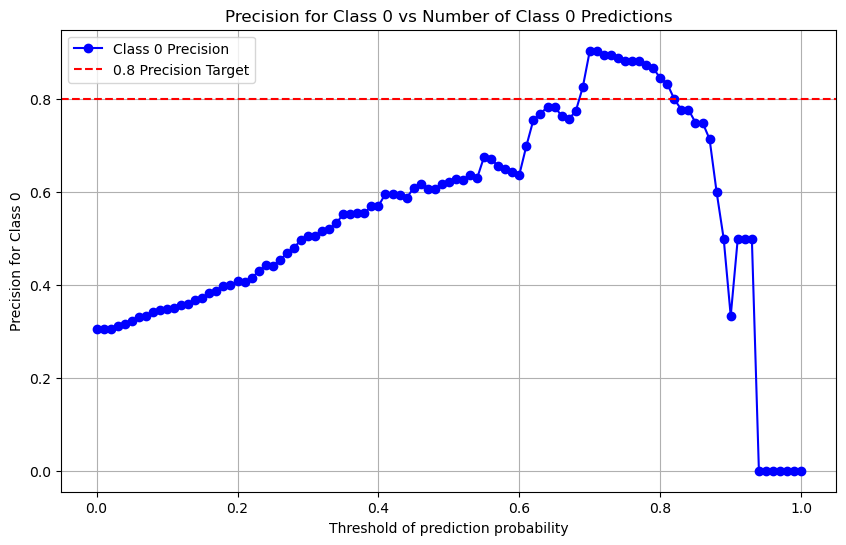

In [93]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have your model and test set ready
# Get predicted probabilities for class 0 (probability of class 0)
predicted_proba = best_rf_model_with_z.predict_proba(X_df_test.iloc[:, 2:])[:, 0]  # Probability of class 0

# Initialize variables to track the best threshold and its corresponding precision for class 0
best_threshold = None
best_precision = 0.0
best_num_class_0_predictions = 0
best_conf_matrix = None

# Lists to store thresholds, precision for class 0, and number of class 0 predictions
thresholds = np.arange(0.0, 1.01, 0.01)  # Include 1.0
precision_values_with_z = []
num_class_0_predictions_with_z = []

# Evaluate thresholds from 0.0 to 1.0 in steps (e.g., 0.01)
for threshold in thresholds:
    # Make predictions based on the current threshold
    # Predict class 0 if prob of 0 >= threshold, else class 1
    predictions = (1-(predicted_proba >= threshold)).astype(int)  # 0 if prob >= threshold, 1 otherwise
    
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test_encoded, predictions)
    
    # Extract True Negatives (TN) and False Negatives (FN)
    tn = conf_matrix[0, 0]  # True Negatives
    fn = conf_matrix[1, 0]  # False Negatives
    predicted_negatives = tn + fn  # Total predicted negatives (0 predictions)
    
    # Calculate precision for class 0 (TN / (TN + FN))
    precision_class_0 = tn / predicted_negatives if predicted_negatives > 0 else 0
    
    # Track precision and number of class 0 predictions for this threshold
    precision_values_with_z.append(precision_class_0)
    num_class_0_predictions_with_z.append(predicted_negatives)
    
    # Update the best threshold if precision is at least 0.8 and we achieve more class 0 predictions
    if precision_class_0 >= 0.8 and predicted_negatives > best_num_class_0_predictions:
        best_precision = precision_class_0
        best_threshold = threshold
        best_num_class_0_predictions = predicted_negatives
        best_conf_matrix = conf_matrix  # Store the best confusion matrix

# Output the best threshold and corresponding precision for predicting 0
print("Best Threshold with at least 0.8 Precision for Class 0:", best_threshold)
print("Best Class 0 Precision (>= 0.8):", best_precision)
print("Number of Class 0 Predictions at Best Threshold:", best_num_class_0_predictions)

best_threshold_rf_with_z = best_threshold

# Present the corresponding confusion matrix
print("Confusion Matrix with Best Threshold:\n", best_conf_matrix)

# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(num_class_0_predictions_with_z, precision_values_with_z, marker='o', label='Class 0 Precision', color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Number of Class 0 Predictions (TN + FN)")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()


# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_values_with_z, marker='o', label='Class 0 Precision', color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Threshold of prediction probability")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()


In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Predict class labels and probabilities
y_pred = best_rf_model_with_z.predict(X_df_test.iloc[:, 2:])
y_pred_proba = best_rf_model_with_z.predict_proba(X_df_test.iloc[:, 2:])[:, 1]  # Probabilities for the positive class

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba)

# Output metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.7534
Precision: 0.7951
Recall: 0.8687
F1-Score: 0.8303
ROC-AUC: 0.7972

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.49      0.55       114
           1       0.80      0.87      0.83       259

    accuracy                           0.75       373
   macro avg       0.71      0.68      0.69       373
weighted avg       0.74      0.75      0.74       373


Confusion Matrix:
[[ 56  58]
 [ 34 225]]


Feature Importance:
                        Feature  Importance
2                       Charge    0.048297
18            Basic_Percentage    0.043803
36                         z_7    0.042387
30                         z_1    0.042263
29           Isoelectric_point    0.040105
23                       Boman    0.039952
1               Hydrophobicity    0.039884
27  Hydrophobic_moment_ang_100    0.038975
28  Hydrophobic_moment_ang_160    0.037899
26             Auto_covariance    0.037894
25            Auto_correlation    0.037595
34                         z_5    0.037071
21            Molecular_Weight    0.035128
24                 Instability    0.034499
31                         z_2    0.034072
6             Small_Percentage    0.033713
16          Charged_Percentage    0.033347
22             Aliphatic_Index    0.030963
4              Tiny_Percentage    0.028997
8         Aliphatic_Percentage    0.026489
10         Aromatic_Percentage    0.025790
12        Non-polar_Percentage   

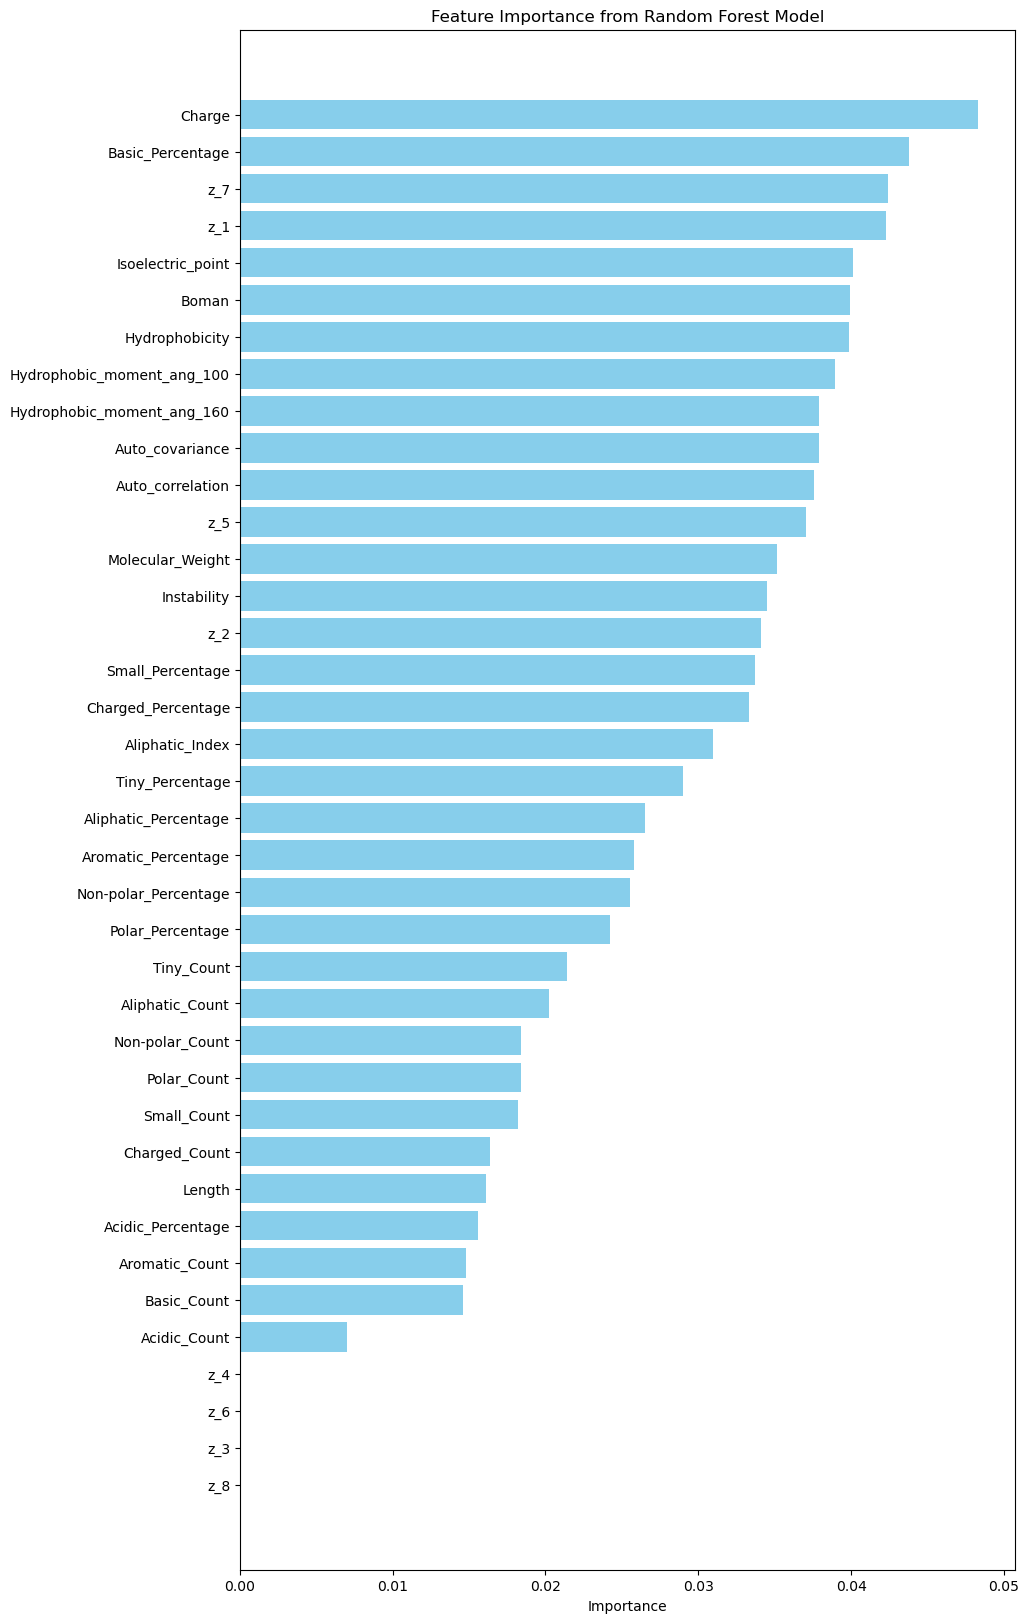

In [95]:
# Feature Importance
importances =best_rf_model_with_z.feature_importances_
feature_names = X_df_train.iloc[:, 2:].columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display feature importance
print("Feature Importance:\n", feature_importance_df)

# Plotting feature importance
plt.figure(figsize=(10, 20))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest Model')
plt.gca().invert_yaxis()  # Invert y axis to have the most important feature at the top
plt.show()

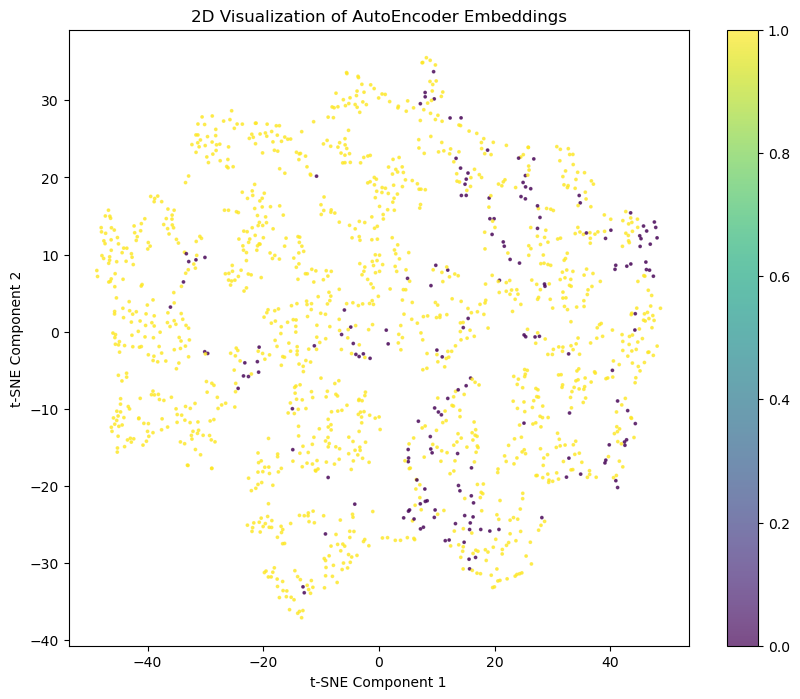

In [96]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
#embedding_CVAE_test = encoded.cpu().detach().numpy()
# Use t-SNE to reduce dimensionality to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embedding_CVAE_train[:, [0, 1, 4, 6]])
#embeddings_2d = embedding_CVAE_train[:, [1, 7]]
# Plot the 2D embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s = 3, c=df_train['Length_pos'])
plt.colorbar(scatter)  # Add a color bar to indicate labels
plt.title('2D Visualization of AutoEncoder Embeddings')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

/home/deliangyang/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


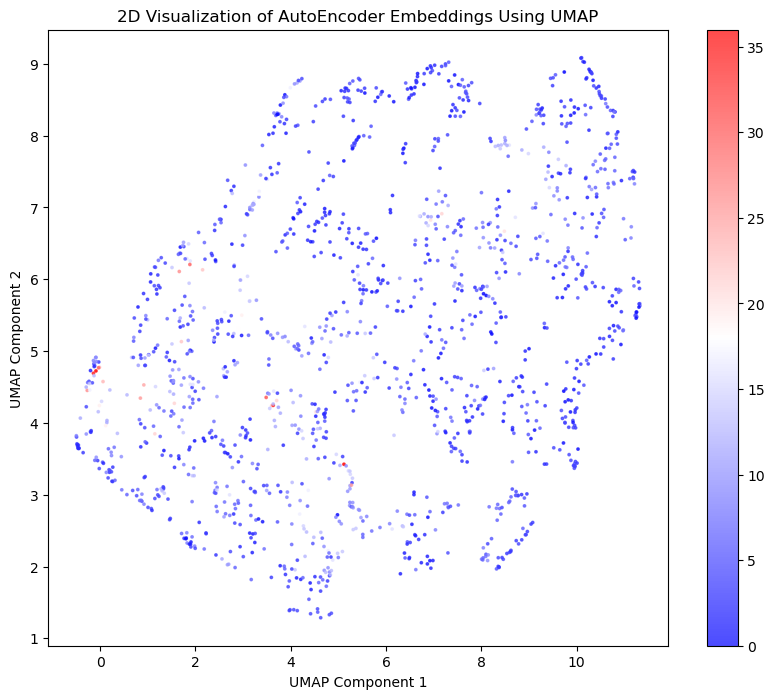

In [97]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap # Correct import for UMAP from umap-learn

# embedding_CVAE_test = encoded.cpu().detach().numpy()

# Use UMAP to reduce dimensionality to 2D for visualization
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embedding_CVAE_train[:, [0, 1, 4, 6]])

# Plot the 2D embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=3, c=X_df_train['Charged_Count'],cmap= 'bwr')

# Add a color bar to indicate labels
plt.colorbar(scatter)

# Set plot titles and labels
plt.title('2D Visualization of AutoEncoder Embeddings Using UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

# Show the plot
plt.show()

/home/deliangyang/anaconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


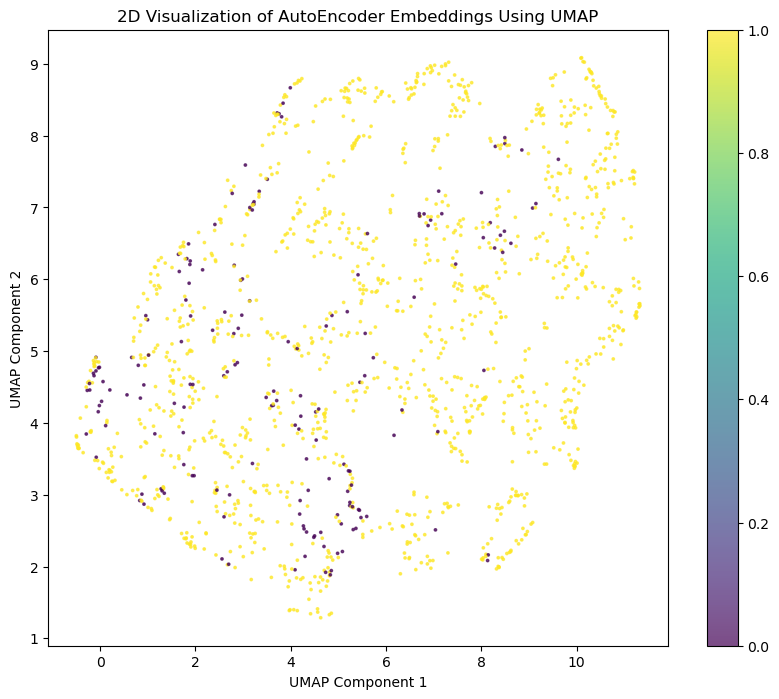

In [98]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap # Correct import for UMAP from umap-learn

# embedding_CVAE_test = encoded.cpu().detach().numpy()

# Use UMAP to reduce dimensionality to 2D for visualization
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embedding_CVAE_train)

# Plot the 2D embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=3, c=df_train['Length_pos'])

# Add a color bar to indicate labels
plt.colorbar(scatter)

# Set plot titles and labels
plt.title('2D Visualization of AutoEncoder Embeddings Using UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

# Show the plot
plt.show()

# **Linear Model not following the generator**

In [99]:
import pandas as pd
import numpy as np

# Step 1: Read the CSV file
# Replace 'peptides.csv' with your actual file path
#df = pd.read_csv('APD_ac_10_label.csv')
import numpy as np
# Create a variable for length
#df['Length'] = df['Sequence'].apply(len)
# Step 1: Extract the relevant columns from the DataFrame
# Selecting "Length", "Sequence", and "APD ID" columns
X_df_train = df_train[[ 'APD ID','Sequence','Length', 'Hydrophobicity','Charge']]
X_df_test = df_test[[ 'APD ID','Sequence','Length', 'Hydrophobicity','Charge']]


In [ ]:
properties_df_AA_train = X_df_train['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_train = properties_df_AA_train.iloc[:, 1:]
properties_df_AA_test = X_df_test['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_train = X_df_train['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)
properties_df_fea_test = X_df_test['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_train = np.array(df_train['OneHotEncoded'].tolist())
X_test = np.array(df_test['OneHotEncoded'].tolist())
z_train_all = extract_z(trained_cvae, X_train, device=device)
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_train_df = pd.DataFrame(z_train_all, columns=[f'z_{i+1}' for i in range(z_train_all.shape[1])])
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])
z_train_df_reset = z_train_df.reset_index(drop=True)
z_test_df_reset = z_test_df.reset_index(drop=True)


In [103]:

# Concatenate the new properties with the original DataFrame
X_df_train = pd.concat([X_df_train.reset_index(drop=True), properties_df_AA_train.reset_index(drop=True) , properties_df_fea_train.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_df_test = pd.concat([X_df_test.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True)], axis=1)



In [104]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_val are pandas Series containing 'Inactive' and 'Active'
# Example:
# y_train = pd.Series(['Active', 'Inactive', 'Active', ...])
# y_val = pd.Series(['Inactive', 'Active', ...])

# Step 1: Initialize LabelEncoder
label_encoder = LabelEncoder()

# Step 2: Fit and transform your labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Step 2: Fit and transform your labels
y_test_encoded = label_encoder.fit_transform(y_test)
y_test_res = np.array(y_test_encoded.astype('float32').reshape((-1, 1)))

In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [106]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Implement GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_df_train.iloc[:, 2:], y_train_encoded)

# Best model and parameters
best_rf_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/home/deliangyang/anaconda3/lib/python3.10/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constr

Best Parameters: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


Confusion Matrix:
 [[ 52  62]
 [ 27 232]]


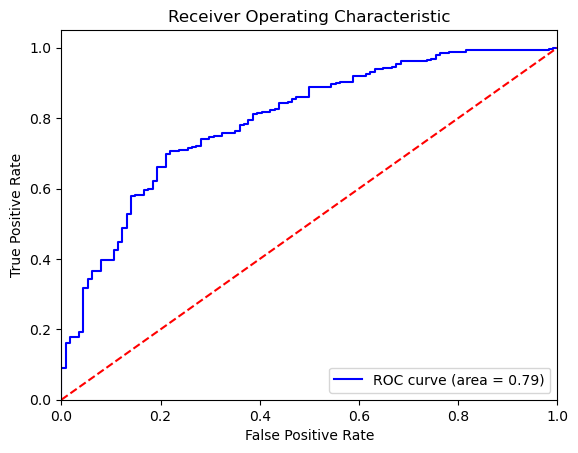

In [107]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Example data creation (replace this with your actual data loading)
from sklearn.datasets import make_classification


# Make predictions
predictions = best_rf_model.predict(X_df_test.iloc[:, 2:])
predicted_proba = best_rf_model.predict_proba(X_df_test.iloc[:, 2:])[:, 1]  # Probability estimates for the positive class

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, predictions)
print("Confusion Matrix:\n", conf_matrix)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_encoded, predicted_proba)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [108]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Assuming you have your model and test set ready
# Get predicted probabilities for class 0 (probability of class 0)
predicted_proba = best_rf_model.predict_proba(X_df_test.iloc[:, 2:])[:, 0]  # Probability of class 0

# Initialize variables to track the best threshold and its corresponding precision for class 0
best_threshold = 0.0
best_precision = 0.0
best_conf_matrix = None

# Evaluate thresholds from 0.0 to 1.0 in steps (e.g., 0.01)
thresholds = np.arange(0.0, 1.01, 0.01)  # Include 1.0
thresholds = np.arange(0.58, 0.61, 0.01)
for threshold in thresholds:
    # Make predictions based on the current threshold
    # Predict class 0 if prob of 0 >= threshold, else class 1
    predictions = (1-(predicted_proba >= threshold)).astype(int)  # 0 if prob >= threshold, 1 otherwise
    
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test_encoded, predictions)
    
    # Extract True Negatives (TN) and False Negatives (FN)
    tn = conf_matrix[0, 0]  # True Negatives
    fn = conf_matrix[1, 0]  # False Negatives
    predicted_negatives = tn + fn  # Total predicted negatives (0 predictions)
    
    # Calculate precision for class 0 (TN / (TN + FN))
    precision_class_0 = tn / predicted_negatives if predicted_negatives > 0 else 0
    
    # Update the best threshold if the current precision is higher
    if precision_class_0 > best_precision:
        best_precision = precision_class_0
        best_threshold = threshold
        best_conf_matrix = conf_matrix  # Store the best confusion matrix

# Output the best threshold and corresponding precision for predicting 0
print("Best Threshold for Class 0 Precision:", best_threshold)
print("Best Class 0 Prediction Precision:", best_precision)

# Present the corresponding confusion matrix
print("Confusion Matrix with Best Threshold:\n", best_conf_matrix)

Best Threshold for Class 0 Precision: 0.6
Best Class 0 Prediction Precision: 0.782608695652174
Confusion Matrix with Best Threshold:
 [[ 36  78]
 [ 10 249]]


Best Threshold with at least 0.8 Precision for Class 0: 0.66
Best Class 0 Precision (>= 0.8): 0.84375
Number of Class 0 Predictions at Best Threshold: 32
Confusion Matrix with Best Threshold:
 [[ 27  87]
 [  5 254]]


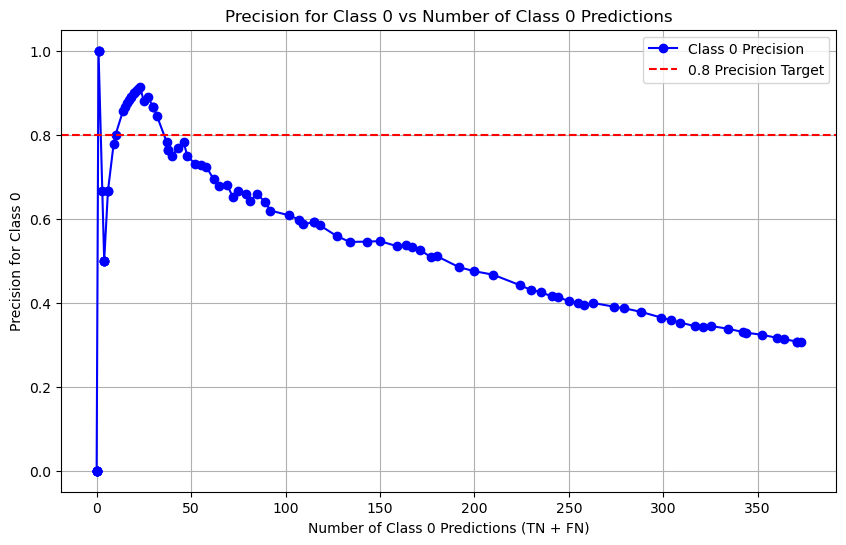

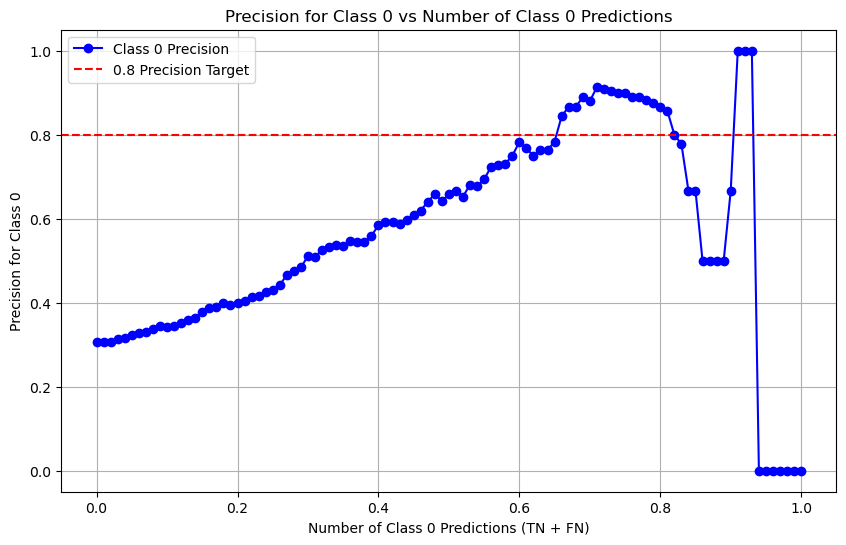

In [109]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have your model and test set ready
# Get predicted probabilities for class 0 (probability of class 0)
predicted_proba = best_rf_model.predict_proba(X_df_test.iloc[:, 2:])[:, 0]  # Probability of class 0

# Initialize variables to track the best threshold and its corresponding precision for class 0
best_threshold = None
best_precision = 0.0
best_num_class_0_predictions = 0
best_conf_matrix = None

# Lists to store thresholds, precision for class 0, and number of class 0 predictions
thresholds = np.arange(0.0, 1.01, 0.01)  # Include 1.0
precision_values = []
num_class_0_predictions = []

# Evaluate thresholds from 0.0 to 1.0 in steps (e.g., 0.01)
for threshold in thresholds:
    # Make predictions based on the current threshold
    # Predict class 0 if prob of 0 >= threshold, else class 1
    predictions = (1-(predicted_proba >= threshold)).astype(int)  # 0 if prob >= threshold, 1 otherwise
    
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test_encoded, predictions)
    
    # Extract True Negatives (TN) and False Negatives (FN)
    tn = conf_matrix[0, 0]  # True Negatives
    fn = conf_matrix[1, 0]  # False Negatives
    predicted_negatives = tn + fn  # Total predicted negatives (0 predictions)
    
    # Calculate precision for class 0 (TN / (TN + FN))
    precision_class_0 = tn / predicted_negatives if predicted_negatives > 0 else 0
    
    # Track precision and number of class 0 predictions for this threshold
    precision_values.append(precision_class_0)
    num_class_0_predictions.append(predicted_negatives)
    
    # Update the best threshold if precision is at least 0.8 and we achieve more class 0 predictions
    if precision_class_0 >= 0.8 and predicted_negatives > best_num_class_0_predictions:
        best_precision = precision_class_0
        best_threshold = threshold
        best_num_class_0_predictions = predicted_negatives
        best_conf_matrix = conf_matrix  # Store the best confusion matrix
        
# Output the best threshold and corresponding precision for predicting 0
print("Best Threshold with at least 0.8 Precision for Class 0:", best_threshold)
print("Best Class 0 Precision (>= 0.8):", best_precision)
print("Number of Class 0 Predictions at Best Threshold:", best_num_class_0_predictions)
best_threshold_rf_without_z = best_threshold
# Present the corresponding confusion matrix
print("Confusion Matrix with Best Threshold:\n", best_conf_matrix)

# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(num_class_0_predictions, precision_values, marker='o', label='Class 0 Precision', color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Number of Class 0 Predictions (TN + FN)")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()

# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_values, marker='o', label='Class 0 Precision', color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Number of Class 0 Predictions (TN + FN)")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()




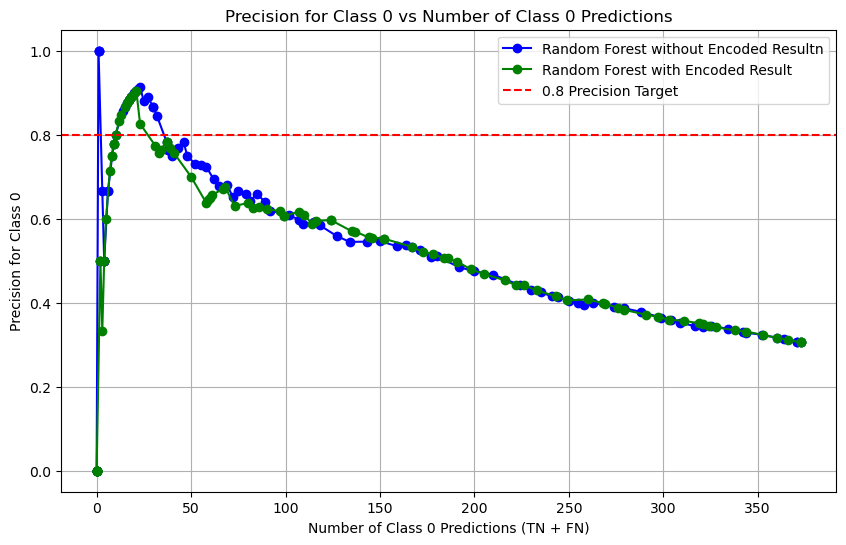

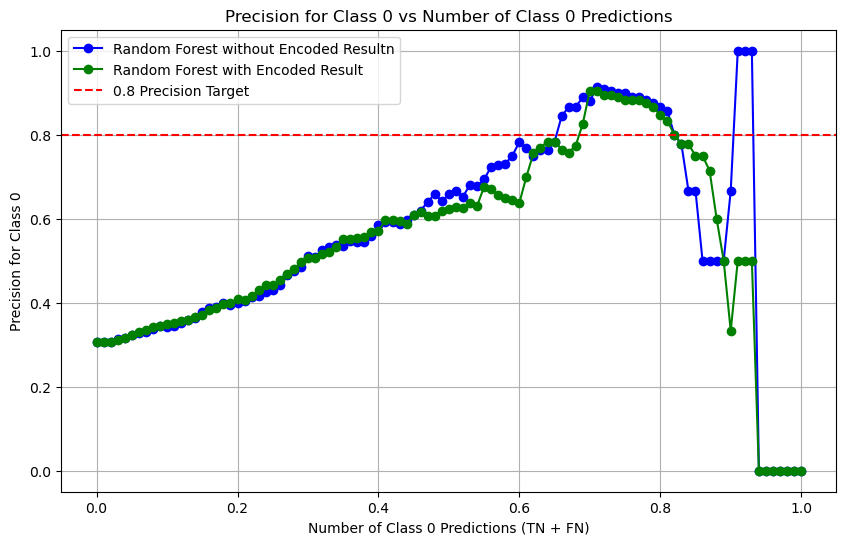

In [110]:
# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(num_class_0_predictions, precision_values, marker='o', label='Random Forest without Encoded Resultn', color='b')
plt.plot(num_class_0_predictions_with_z, precision_values_with_z, marker='o', label='Random Forest with Encoded Result', color='g')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Number of Class 0 Predictions (TN + FN)")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()

# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_values, marker='o', label='Random Forest without Encoded Resultn', color='b')
plt.plot(thresholds, precision_values_with_z, marker='o', label='Random Forest with Encoded Result', color='g')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Number of Class 0 Predictions (TN + FN)")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()


In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Predict class labels and probabilities
y_pred = best_rf_model.predict(X_df_test.iloc[:, 2:])
y_pred_proba = best_rf_model.predict_proba(X_df_test.iloc[:, 2:])[:, 1]  # Probabilities for the positive class

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba)

# Output metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.7614
Precision: 0.7891
Recall: 0.8958
F1-Score: 0.8391
ROC-AUC: 0.7940

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.46      0.54       114
           1       0.79      0.90      0.84       259

    accuracy                           0.76       373
   macro avg       0.72      0.68      0.69       373
weighted avg       0.75      0.76      0.75       373


Confusion Matrix:
[[ 52  62]
 [ 27 232]]


Feature Importance:
                        Feature  Importance
2                       Charge    0.068564
23                       Boman    0.050779
27  Hydrophobic_moment_ang_100    0.049505
28  Hydrophobic_moment_ang_160    0.047622
29           Isoelectric_point    0.045737
1               Hydrophobicity    0.044000
21            Molecular_Weight    0.043677
24                 Instability    0.043603
16          Charged_Percentage    0.042533
18            Basic_Percentage    0.041785
25            Auto_correlation    0.040673
26             Auto_covariance    0.038792
6             Small_Percentage    0.036898
10         Aromatic_Percentage    0.035948
22             Aliphatic_Index    0.035427
4              Tiny_Percentage    0.034663
8         Aliphatic_Percentage    0.033061
12        Non-polar_Percentage    0.029259
14            Polar_Percentage    0.027794
5                  Small_Count    0.027020
7              Aliphatic_Count    0.022570
3                   Tiny_Count   

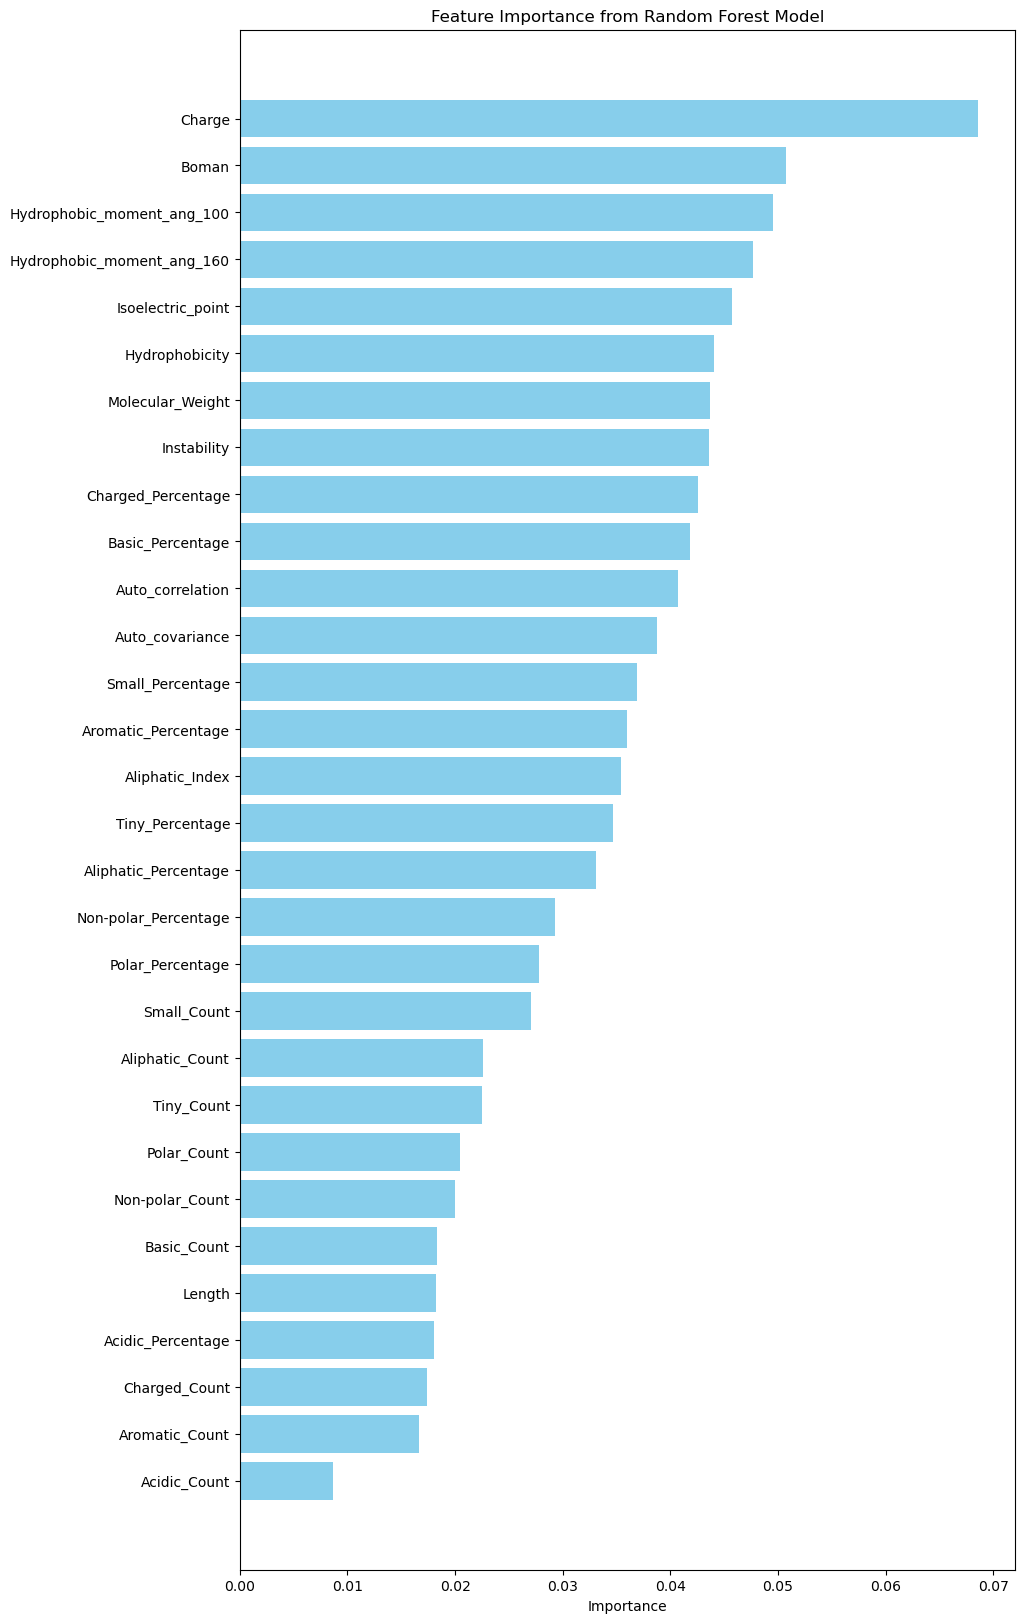

In [112]:
# Feature Importance
importances = best_rf_model.feature_importances_
feature_names = X_df_train.iloc[:, 2:].columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display feature importance
print("Feature Importance:\n", feature_importance_df)

# Plotting feature importance
plt.figure(figsize=(10, 20))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest Model')
plt.gca().invert_yaxis()  # Invert y axis to have the most important feature at the top
plt.show()

# Generated Peptide Filtering

Filter the generated_results_df_train

In [113]:
# Initialize X_generated_results_df_train as a pandas DataFrame
X_generated_results_df_train = pd.DataFrame()

# Copy specific columns from generated_results_df_train to X_generated_results_df_train
X_generated_results_df_train[['APD ID', 'Sequence', 'Length', 'Hydrophobicity','Charge']] = generated_results_df_train[['APD ID', 'Reconstructed_sequences', 'Length_re', 'Hydrophobicity_re', 'Charge_re']]

In [ ]:
properties_df_AA_test = X_generated_results_df_train['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_test = X_generated_results_df_train['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_test = np.array(X_generated_results_df_train['Sequence'].apply(one_hot_encode_sequence).tolist())
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])


In [117]:

# Concatenate the new properties with the original DataFrame
X_generated_results_df_train_with_z = pd.concat([X_generated_results_df_train.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True),z_test_df.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_generated_results_df_train_without_z = pd.concat([X_generated_results_df_train.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True)], axis=1)



In [118]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_val are pandas Series containing 'Inactive' and 'Active'
# Example:
# y_train = pd.Series(['Active', 'Inactive', 'Active', ...])
# y_val = pd.Series(['Inactive', 'Active', ...])

# Step 1: Initialize LabelEncoder
label_encoder = LabelEncoder()

# Step 2: Fit and transform your labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Step 2: Fit and transform your labels
y_test_encoded = label_encoder.fit_transform(y_test)
y_test_res = np.array(y_test_encoded.astype('float32').reshape((-1, 1)))

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [120]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Example data creation (replace this with your actual data loading)
from sklearn.datasets import make_classification


# Make predictions
threshold_best_rf_model_with_z = best_threshold_rf_with_z
predicted_proba_X_generated_results_df_train_with_z = best_rf_model_with_z.predict_proba(X_generated_results_df_train_with_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_train_with_z = (1-(predicted_proba_X_generated_results_df_train_with_z >= threshold_best_rf_model_with_z)).astype(int) 
# Make predictions
threshold_best_rf_model_without_z = best_threshold_rf_without_z
predicted_proba_X_generated_results_df_train_without_z = best_rf_model.predict_proba(X_generated_results_df_train_without_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_train_without_z = (1-(predicted_proba_X_generated_results_df_train_without_z >= threshold_best_rf_model_without_z)).astype(int) 


Filter the generated_results_df_train_generated

In [121]:
# Initialize X_generated_results_df_train as a pandas DataFrame
X_generated_results_df_train_generated = pd.DataFrame()

# Copy specific columns from generated_results_df_train to X_generated_results_df_train
X_generated_results_df_train_generated[['APD ID', 'Sequence', 'Length', 'Hydrophobicity','Charge']] = generated_results_df_train_generated[['APD ID', 'Reconstructed_sequences', 'Length_re', 'Hydrophobicity_re', 'Charge_re']]

In [ ]:
properties_df_AA_test = X_generated_results_df_train_generated['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_test = X_generated_results_df_train_generated['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_test = np.array(X_generated_results_df_train_generated['Sequence'].apply(one_hot_encode_sequence).tolist())
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])


In [125]:

# Concatenate the new properties with the original DataFrame
X_generated_results_df_train_generated_with_z = pd.concat([X_generated_results_df_train_generated.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True),z_test_df.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_generated_results_df_train_generated_without_z = pd.concat([X_generated_results_df_train_generated.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True)], axis=1)



In [126]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [127]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Example data creation (replace this with your actual data loading)
from sklearn.datasets import make_classification


# Make predictions
threshold_best_rf_model_with_z = best_threshold_rf_with_z
predicted_proba_X_generated_results_df_train_generated_with_z = best_rf_model_with_z.predict_proba(X_generated_results_df_train_generated_with_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_train_generated_with_z = (1-(predicted_proba_X_generated_results_df_train_with_z >= threshold_best_rf_model_with_z)).astype(int) 
# Make predictions
threshold_best_rf_model_without_z = best_threshold_rf_without_z
predicted_proba_X_generated_results_df_train_generated_without_z = best_rf_model.predict_proba(X_generated_results_df_train_generated_without_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_train_generated_without_z = (1-(predicted_proba_X_generated_results_df_train_without_z >= threshold_best_rf_model_without_z)).astype(int) 


Filter the generated_results_df_test

In [128]:
# Initialize X_generated_results_df_train as a pandas DataFrame
X_generated_results_df_test = pd.DataFrame()

# Copy specific columns from generated_results_df_train to X_generated_results_df_train
X_generated_results_df_test[['APD ID', 'Sequence', 'Length', 'Hydrophobicity','Charge']] = generated_results_df_test[['APD ID', 'Reconstructed_sequences', 'Length_re', 'Hydrophobicity_re', 'Charge_re']]

In [ ]:
properties_df_AA_test = X_generated_results_df_test['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_test = X_generated_results_df_test['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_test = np.array(X_generated_results_df_test['Sequence'].apply(one_hot_encode_sequence).tolist())
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])


In [132]:

# Concatenate the new properties with the original DataFrame
X_generated_results_df_test_with_z = pd.concat([X_generated_results_df_test.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True),z_test_df.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_generated_results_df_test_without_z = pd.concat([X_generated_results_df_test.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True)], axis=1)



In [133]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Example data creation (replace this with your actual data loading)
from sklearn.datasets import make_classification


# Make predictions
threshold_best_rf_model_with_z = best_threshold_rf_with_z
predicted_proba_X_generated_results_df_test_with_z = best_rf_model_with_z.predict_proba(X_generated_results_df_test_with_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_test_with_z = (1-(predicted_proba_X_generated_results_df_test_with_z >= threshold_best_rf_model_with_z)).astype(int) 
# Make predictions
threshold_best_rf_model_without_z = best_threshold_rf_without_z
predicted_proba_X_generated_results_df_test_without_z = best_rf_model.predict_proba(X_generated_results_df_test_without_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_test_without_z = (1-(predicted_proba_X_generated_results_df_test_without_z >= threshold_best_rf_model_without_z)).astype(int) 


Filter the generated_results_df_test_generated

In [135]:
# Initialize X_generated_results_df_train as a pandas DataFrame
X_generated_results_df_test_generated = pd.DataFrame()

# Copy specific columns from generated_results_df_train to X_generated_results_df_train
X_generated_results_df_test_generated[['APD ID', 'Sequence', 'Length', 'Hydrophobicity','Charge']] = generated_results_df_test_generated[['APD ID', 'Reconstructed_sequences', 'Length_re', 'Hydrophobicity_re', 'Charge_re']]

In [ ]:
properties_df_AA_test = X_generated_results_df_test_generated['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_test = X_generated_results_df_test_generated['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_test = np.array(X_generated_results_df_test_generated['Sequence'].apply(one_hot_encode_sequence).tolist())
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])


In [139]:

# Concatenate the new properties with the original DataFrame
X_generated_results_df_test_generated_with_z = pd.concat([X_generated_results_df_test_generated.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True),z_test_df.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_generated_results_df_test_generated_without_z = pd.concat([X_generated_results_df_test_generated.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True)], axis=1)



In [140]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Example data creation (replace this with your actual data loading)
from sklearn.datasets import make_classification


# Make predictions
threshold_best_rf_model_with_z = best_threshold_rf_with_z
predicted_proba_X_generated_results_df_test_generated_with_z = best_rf_model_with_z.predict_proba(X_generated_results_df_test_generated_with_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_test_generated_with_z = (1-(predicted_proba_X_generated_results_df_test_generated_with_z >= threshold_best_rf_model_with_z)).astype(int) 
# Make predictions
threshold_best_rf_model_without_z = best_threshold_rf_without_z
predicted_proba_X_generated_results_df_test_generated_without_z = best_rf_model.predict_proba(X_generated_results_df_test_generated_without_z.iloc[:, 2:])[:, 0]  # Probability estimates for the positive class
predictions_X_generated_results_df_test_generated_without_z = (1-(predicted_proba_X_generated_results_df_test_generated_without_z >= threshold_best_rf_model_without_z)).astype(int) 


In [151]:
threshold_best_rf_model_without_z

0.66

In [ ]:
predicted_proba_X_generated_results_df_train_without_z

array([0.20183333, 0.33      , 0.37890476, 0.51267857, 0.3722619 ,
       0.30257143, 0.27259524, 0.56947619, 0.4302381 , 0.11542857,
       0.39394048, 0.52724892, 0.22457143, 0.40022222, 0.44633333,
       0.25290476, 0.69982143, 0.3822381 , 0.71768651, 0.09392857,
       0.39240476, 0.3527381 , 0.29950794, 0.44859524, 0.14242857,
       0.45728571, 0.42703175, 0.17125   , 0.62591558, 0.24485714,
       0.55574603, 0.65330952, 0.42330159, 0.27233333, 0.61464286,
       0.48680952, 0.17802381, 0.2625    , 0.27088889, 0.1852381 ,
       0.71832143, 0.4465119 , 0.49516667, 0.23166667, 0.14411905,
       0.3381746 , 0.2577381 , 0.40082143, 0.21295238, 0.37890476,
       0.22521429, 0.51690476, 0.26872619, 0.67854762, 0.19116667,
       0.69982143, 0.42350794, 0.08985714, 0.43279762, 0.23340476,
       0.35125   , 0.41185714, 0.31097619, 0.46016667, 0.182     ,
       0.69982143, 0.42896429, 0.24666667, 0.2252381 , 0.66174603,
       0.60332143, 0.19090476, 0.25090476, 0.326     , 0.16383

In [147]:
# List all variables with shape (1490, *)
for var_name, var_value in list(globals().items()):  # Make a copy of globals()
    if isinstance(var_value, (np.ndarray, pd.DataFrame)) and var_value.shape[0] == 1490:
        print(f"Variable '{var_name}' has shape {var_value.shape}")

Variable 'df_train' has shape (1490, 21)
Variable 'y_1' has shape (1490,)
Variable 'y_2' has shape (1490,)
Variable 'y_3' has shape (1490,)
Variable 'y_4' has shape (1490,)
Variable 'y_5' has shape (1490,)
Variable 'z_all' has shape (1490, 8)
Variable 'z_2d' has shape (1490, 2)
Variable 'embedding_CVAE_train' has shape (1490, 8)
Variable 'generated_results_df_train' has shape (1490, 16)
Variable 'embedding_CVAE_train_recontruct' has shape (1490, 8)
Variable 'generated_results_df_train_generated' has shape (1490, 15)
Variable 'embeddings_2d' has shape (1490, 2)
Variable 'X_df_train' has shape (1490, 32)
Variable 'properties_df_AA_train' has shape (1490, 18)
Variable 'properties_df_fea_train' has shape (1490, 9)
Variable 'X_train' has shape (1490, 3100)
Variable 'z_train_df' has shape (1490, 8)
Variable 'z_train_df_reset' has shape (1490, 8)
Variable 'y_train_encoded' has shape (1490,)
Variable 'X_generated_results_df_train' has shape (1490, 5)
Variable 'X_generated_results_df_train_with

In [ ]:
predicted_proba_X_generated_results_df_train_generated_without_z

,APD ID,Sequence,Label,Reconstructed_sequences,Active_proba,Boman_ori,Boman_re,Hydrophobicity_ori,Hydrophobicity_re,Length_ori,Length_re,Stability_ori,Stability_re,Charge_ori,Charge_re,OneHotEncoded
710,AP02273,FITGLIGGLMKAL,Inactive,ILWKAIPDAVKKVISL,1,-2.03,-0.62,1.623077,0.912500,13,16,12.19,22.59,0.997689,1.997546,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
1708,AP04535,IWSFLIKAATKLLPSLFGGGKKFS,Inactive,LSFLIKGATKLLPSLFGGGKK,1,-0.51,-0.45,0.575000,0.466667,24,21,25.30,19.40,3.996804,3.996804,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
402,AP01429,GLLDSFKNAMIGIAKSAGKTALNKIACKIDKTC,Inactive,GLLSGVLGVGKKIVCGVRGLC,1,0.66,-0.93,0.196970,1.238095,33,21,18.61,-10.69,3.873158,2.873441,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1048,AP03248,FIGTLIPLALGALTKLFK,Inactive,FLWKLIPKAISAVTSLIKK,1,-1.65,-0.57,1.422222,0.794737,18,19,-14.66,7.02,1.997394,3.996804,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1396,AP03864,GLRCRLGRLLRRLGRC,Inactive,FLWKLIPKAISAVITLIKKI,1,3.72,-1.21,-0.262500,1.245000,16,20,69.25,7.17,5.874015,3.996804,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,AP02825,RERSKGSKYLYVG,Inactive,IKWKAILDAIKKVIKK,1,3.38,0.46,-1.330769,0.112500,13,16,29.97,0.19,2.997462,4.996661,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
552,AP01857,GLFSKFAGKGIKDLIFKGVKHIGKEVGMDVIRVGIDVAGCKIKGVC,Active,GLFSKGFGIALKGGQEVKMGLLVAKTIK,1,0.24,-0.33,0.465217,0.475000,46,28,-6.71,16.38,4.965695,3.998284,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1763,AP04607,GFCWNVAVYRNGVRVAHRRCN,Active,KWCFYAYVKVKGVLVKYKKCW,1,2.61,-0.01,-0.309524,0.033333,21,21,36.99,35.40,3.964080,5.869713,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
1045,AP03241,GLKDWWNKHKDKIVKVVKEMGKAGINAA,Inactive,GIWKVLKNLAKGAGTSAASA,1,1.39,-0.02,-0.653571,0.285000,28,20,7.68,-15.97,4.089496,2.997099,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
df_train

array([1, 1, 1, ..., 0, 1, 0])

# **Linear Model SVM following the generator**

In [94]:
import pandas as pd
import numpy as np

# Step 1: Read the CSV file
# Replace 'peptides.csv' with your actual file path
#df = pd.read_csv('APD_ac_10_label.csv')
import numpy as np
# Create a variable for length
#df['Length'] = df['Sequence'].apply(len)
# Step 1: Extract the relevant columns from the DataFrame
# Selecting "Length", "Sequence", and "APD ID" columns
X_df_train = df_train[[ 'APD ID','Sequence','Length', 'Hydrophobicity','Amphiphilicity','Charge']]
X_df_test = df_test[[ 'APD ID','Sequence','Length', 'Hydrophobicity','Amphiphilicity','Charge']]


In [ ]:
properties_df_AA_train = X_df_train['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_train = properties_df_AA_train.iloc[:, 1:]
properties_df_AA_test = X_df_test['Sequence'].apply(calculate_amino_acid_class_properties).apply(pd.Series)
properties_df_AA_test = properties_df_AA_test.iloc[:, 1:]


In [ ]:
properties_df_fea_train = X_df_train['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)
properties_df_fea_test = X_df_test['Sequence'].apply(calculate_physicochemical_properties).apply(pd.Series)


In [ ]:
X_train = np.array(df_train['OneHotEncoded'].tolist())
X_test = np.array(df_test['OneHotEncoded'].tolist())
z_train_all = extract_z(trained_cvae, X_train, device=device)
z_test_all = extract_z(trained_cvae, X_test, device=device)
z_train_df = pd.DataFrame(z_train_all, columns=[f'z_{i+1}' for i in range(z_train_all.shape[1])])
z_test_df = pd.DataFrame(z_test_all, columns=[f'z_{i+1}' for i in range(z_test_all.shape[1])])
z_train_df_reset = z_train_df.reset_index(drop=True)
z_test_df_reset = z_test_df.reset_index(drop=True)


In [97]:
# Convert the z_all array to a DataFrame and rename columns
z_train_df = pd.DataFrame(embedding_CVAE_train , columns=[f'z_{i+1}' for i in range(embedding_CVAE_train.shape[1])])
z_test_df = pd.DataFrame(embedding_CVAE_test, columns=[f'z_{i+1}' for i in range(embedding_CVAE_test.shape[1])])

# Reset the indices of both DataFrames to ensure alignment
z_train_df_reset = z_train_df.reset_index(drop=True)
z_test_df_reset = z_test_df.reset_index(drop=True)

In [98]:

# Concatenate the new properties with the original DataFrame
X_df_train = pd.concat([X_df_train.reset_index(drop=True), properties_df_AA_train.reset_index(drop=True) , properties_df_fea_train.reset_index(drop=True),z_train_df.reset_index(drop=True)], axis=1)
# Concatenate the new properties with the original DataFrame
X_df_test = pd.concat([X_df_test.reset_index(drop=True), properties_df_AA_test.reset_index(drop=True), properties_df_fea_test.reset_index(drop=True),z_test_df.reset_index(drop=True)], axis=1)



In [99]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_val are pandas Series containing 'Inactive' and 'Active'
# Example:
# y_train = pd.Series(['Active', 'Inactive', 'Active', ...])
# y_val = pd.Series(['Inactive', 'Active', ...])

# Step 1: Initialize LabelEncoder
label_encoder = LabelEncoder()

# Step 2: Fit and transform your labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Step 2: Fit and transform your labels
y_test_encoded = label_encoder.fit_transform(y_test)
y_test_res = np.array(y_test_encoded.astype('float32').reshape((-1, 1)))

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import make_classification

In [101]:
import numpy as np
import libsvm
from libsvm.svmutil import *
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [102]:
# Assuming X_train and y_train_encoded are already defined and preprocessed

# Define the parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],  # Only used when kernel='poly'
}

# Convert string kernels to libsvm kernel codes
kernel_mapping = {
    'linear': 0,
    'poly': 1,
    'rbf': 2,
    'sigmoid': 3
}

# Convert gamma strings to numerical values
def get_gamma_value(gamma_str, X_train):
    if gamma_str == 'scale':
        return 1 / (X_train.shape[1] * np.var(X_train))  # 1 / (n_features * X.var())
    elif gamma_str == 'auto':
        return 1 / X_train.shape[1]  # 1 / n_features
    else:
        return float(gamma_str)

# Initialize variables to store the best results
best_accuracy = 0
best_params = None
best_model = None

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Standardize the data (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_df_train.iloc[:, 2:])
y_train = y_train_encoded  # Assuming this is already encoded

# Manual grid search over the parameter grid
for C in param_grid['C']:
    for kernel in param_grid['kernel']:
        kernel_code = kernel_mapping[kernel]

        for gamma in param_grid['gamma']:
            gamma_value = get_gamma_value(gamma, X_train_scaled)

            # For polynomial kernel, also iterate over the degree parameter
            if kernel == 'poly':
                for degree in param_grid['degree']:
                    # Prepare the SVM parameters
                    params = f"-s 0 -t {kernel_code} -c {C} -g {gamma_value} -d {degree} -q"
                    
                    # Perform cross-validation
                    accuracies = []
                    for train_index, test_index in cv.split(X_train_scaled, y_train):
                        X_train_fold, X_test_fold = X_train_scaled[train_index], X_train_scaled[test_index]
                        y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

                        # Train the model on the current fold
                        svm_model = svm_train(y_train_fold.tolist(), X_train_fold.tolist(), params)
                        
                        # Make predictions on the validation set
                        p_label, p_acc, p_val = svm_predict(y_test_fold.tolist(), X_test_fold.tolist(), svm_model, '-q')
                        accuracy = accuracy_score(y_test_fold, p_label)
                        accuracies.append(accuracy)

                    # Compute mean cross-validation accuracy
                    mean_accuracy = np.mean(accuracies)

                    # Keep track of the best model
                    if mean_accuracy > best_accuracy:
                        best_accuracy = mean_accuracy
                        best_params = {'C': C, 'kernel': kernel, 'gamma': gamma, 'degree': degree}
                        best_model = svm_model

            else:
                # For non-polynomial kernels, we don't need the degree parameter
                params = f"-s 0 -t {kernel_code} -c {C} -g {gamma_value} -q"

                # Perform cross-validation
                accuracies = []
                for train_index, test_index in cv.split(X_train_scaled, y_train):
                    X_train_fold, X_test_fold = X_train_scaled[train_index], X_train_scaled[test_index]
                    y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

                    # Train the model on the current fold
                    svm_model = svm_train(y_train_fold.tolist(), X_train_fold.tolist(), params)
                    
                    # Make predictions on the validation set
                    p_label, p_acc, p_val = svm_predict(y_test_fold.tolist(), X_test_fold.tolist(), svm_model, '-q')
                    accuracy = accuracy_score(y_test_fold, p_label)
                    accuracies.append(accuracy)

                # Compute mean cross-validation accuracy
                mean_accuracy = np.mean(accuracies)

                # Keep track of the best model
                if mean_accuracy > best_accuracy:
                    best_accuracy = mean_accuracy
                    best_params = {'C': C, 'kernel': kernel, 'gamma': gamma}
                    best_model = svm_model

# Output the best parameters and accuracy
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_accuracy * 100:.2f}%")

Best Parameters: {'C': 10, 'kernel': 'rbf', 'gamma': 'scale'}
Best Cross-Validation Accuracy: 74.43%


In [103]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
from libsvm.svmutil import *  # Import LIBSVM


In [104]:

# Assuming X_train, X_test, y_train_encoded, y_test_encoded are already defined and scaled

# Use the best model obtained from the manual grid search
# Make sure the model was trained with probability estimates enabled (use `-b 1` during training)
best_params = {'C': 1, 'kernel': 'rbf', 'gamma': 'scale'}  # Example best params (replace with actual best params)

# Extract gamma value from the best params
def get_gamma_value(gamma_str, X_train):
    if gamma_str == 'scale':
        return 1 / (X_train.shape[1] * np.var(X_train))  # 1 / (n_features * X.var())
    elif gamma_str == 'auto':
        return 1 / X_train.shape[1]  # 1 / n_features
    else:
        return float(gamma_str)

# Convert kernel name to LIBSVM kernel code
kernel_mapping = {
    'linear': 0,
    'poly': 1,
    'rbf': 2,
    'sigmoid': 3
}

# Get the parameters
C = best_params['C']
kernel_code = kernel_mapping[best_params['kernel']]
gamma_value = get_gamma_value(best_params['gamma'], X_train_scaled)

# Standardize the data (important for SVM)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_df_test.iloc[:, 2:])


# Train the SVM model with probability estimates enabled (-b 1)
train_params = f"-s 0 -t {kernel_code} -c {C} -g {gamma_value} -b 1 -q"
best_svm_model = svm_train(y_train_encoded.tolist(), X_train_scaled, train_params)


Accuracy = 71.5818% (267/373) (classification)
Confusion Matrix:
 [[ 39  75]
 [ 31 228]]


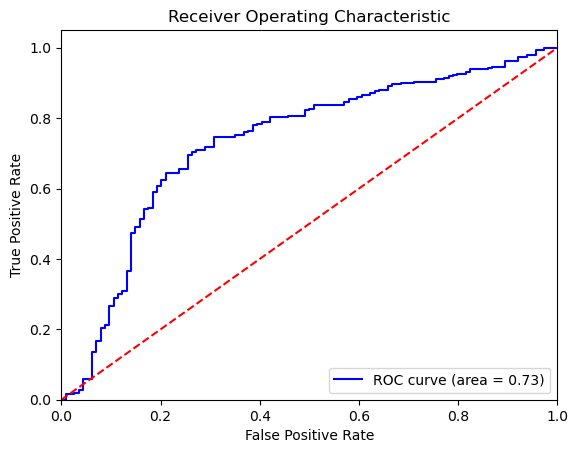

In [105]:

# Make predictions with probability estimates
p_label, p_acc, p_val = svm_predict(y_test_encoded.tolist(), X_test_scaled, best_svm_model, '-b 1')

# LIBSVM returns probabilities in p_val, so we take the probability estimates for the positive class
predictions = np.array(p_label)
predicted_proba = np.array([prob[0] for prob in p_val])  # Extracting probability for the positive class

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, predictions)
print("Confusion Matrix:\n", conf_matrix)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_encoded, predicted_proba)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Best Threshold with at least 0.8 Precision for Class 0: 0.16
Best Class 0 Precision (>= 0.8): 1.0
Number of Class 0 Predictions at Best Threshold: 3
Confusion Matrix with Best Threshold:
 [[  3 111]
 [  0 259]]


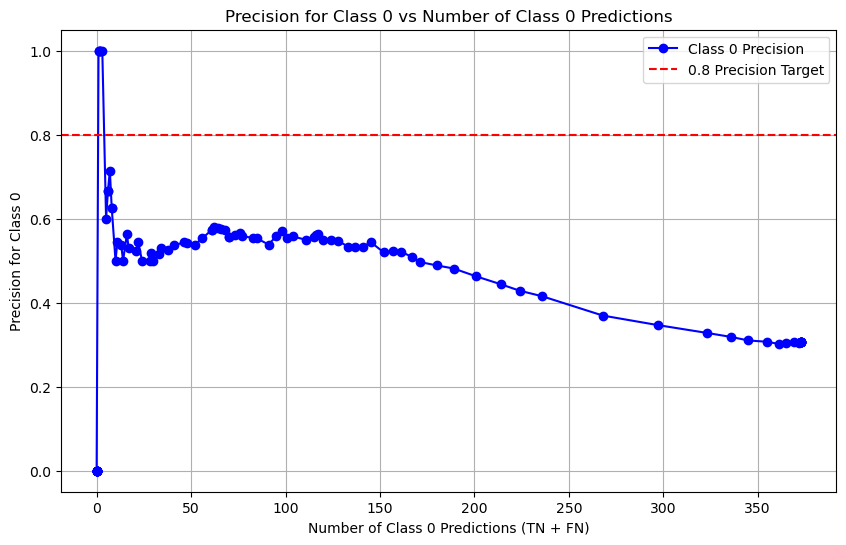

In [106]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have your model and test set ready
# Get predicted probabilities for class 0 (probability of class 0)
#predicted_proba = best_rf_model.predict_proba(X_test.iloc[:, 2:])[:, 0]  # Probability of class 0

# Initialize variables to track the best threshold and its corresponding precision for class 0
best_threshold = None
best_precision = 0.0
best_num_class_0_predictions = 0
best_conf_matrix = None

# Lists to store thresholds, precision for class 0, and number of class 0 predictions
thresholds = np.arange(0.0, 1.01, 0.01)  # Include 1.0
precision_values = []
num_class_0_predictions = []

# Evaluate thresholds from 0.0 to 1.0 in steps (e.g., 0.01)
for threshold in thresholds:
    # Make predictions based on the current threshold
    # Predict class 0 if prob of 0 >= threshold, else class 1
    predictions = (predicted_proba >= threshold).astype(int)  # 0 if prob >= threshold, 1 otherwise
    
    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test_encoded, predictions)
    
    # Extract True Negatives (TN) and False Negatives (FN)
    tn = conf_matrix[0, 0]  # True Negatives
    fn = conf_matrix[1, 0]  # False Negatives
    predicted_negatives = tn + fn  # Total predicted negatives (0 predictions)
    
    # Calculate precision for class 0 (TN / (TN + FN))
    precision_class_0 = tn / predicted_negatives if predicted_negatives > 0 else 0
    
    # Track precision and number of class 0 predictions for this threshold
    precision_values.append(precision_class_0)
    num_class_0_predictions.append(predicted_negatives)
    
    # Update the best threshold if precision is at least 0.8 and we achieve more class 0 predictions
    if precision_class_0 >= 0.8 and predicted_negatives > best_num_class_0_predictions:
        best_precision = precision_class_0
        best_threshold = threshold
        best_num_class_0_predictions = predicted_negatives
        best_conf_matrix = conf_matrix  # Store the best confusion matrix

# Output the best threshold and corresponding precision for predicting 0
print("Best Threshold with at least 0.8 Precision for Class 0:", best_threshold)
print("Best Class 0 Precision (>= 0.8):", best_precision)
print("Number of Class 0 Predictions at Best Threshold:", best_num_class_0_predictions)

# Present the corresponding confusion matrix
print("Confusion Matrix with Best Threshold:\n", best_conf_matrix)

# Plot Precision for Class 0 vs Number of Class 0 Predictions
plt.figure(figsize=(10, 6))
plt.plot(num_class_0_predictions, precision_values, marker='o', label='Class 0 Precision', color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='0.8 Precision Target')  # Add the 0.8 precision line
plt.title("Precision for Class 0 vs Number of Class 0 Predictions")
plt.xlabel("Number of Class 0 Predictions (TN + FN)")
plt.ylabel("Precision for Class 0")
plt.grid(True)
plt.legend()
plt.show()
